<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/EEG_Primary_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Sel instalasi dependensi
%pip -q install "decorator>=4.0.2,<5.0" "mne==1.6.1" "jedi>=0.16" "PyWavelets>=1.4" "h5py>=3.8" "joblib>=1.2" "imbalanced-learn"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.5 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 1 — KONFIGURASI & IMPORT  (UNIFIED v7.1 - Primary Fix)
# ============================================================
from google.colab import drive
from pathlib import Path
import json, re, warnings, h5py, joblib, mne, pywt, decorator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import ipywidgets as widgets
from math import gcd
from hashlib import sha1
from IPython.display import display, clear_output
from scipy.signal import butter, detrend, resample_poly, sosfiltfilt, welch
from scipy.stats import entropy
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              classification_report, ConfusionMatrixDisplay, f1_score)
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")
warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

BASE_DIR               = Path("/content/drive/MyDrive/Creativity-Dataset/")
SECONDARY_DIR          = BASE_DIR / "Secondary"
PRIMARY_RAW_DIR        = BASE_DIR / "Primary-raw"
PRIMARY_MERGED_DIR     = BASE_DIR / "Primary-merged"
PRIMARY_SEGMENTS_CSV   = BASE_DIR / "primary_segments.csv"
CACHE_DIR              = BASE_DIR / "cache"
PREPROCESSED_CACHE_DIR = CACHE_DIR / "preprocessed"
FEATURE_CACHE_DIR      = CACHE_DIR / "features"
OUTPUT_DIR             = BASE_DIR / "output"
for folder in [SECONDARY_DIR, PRIMARY_RAW_DIR, PRIMARY_MERGED_DIR,
               PREPROCESSED_CACHE_DIR, FEATURE_CACHE_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

FS_PRIMARY, FS_SECONDARY, FS_TARGET = 125, 500, 125
BANDPASS_LOW, BANDPASS_HIGH, FILTER_ORDER = 1.0, 40.0, 4

# --- Penyesuaian Toleransi Noise untuk Primary Mode ---
KNOWN_RAIL_ABS_THRESHOLD        = 180000.0
ROBUST_OUTLIER_MAD_MULTIPLIER   = 40.0 # Dinaikkan dari 25.0
MAX_REPAIR_RATIO_PER_CHANNEL    = 0.15 # Dinaikkan dari 0.05 untuk menangani channel F4
bad_channel_z_threshold         = 5.0
BAD_CHANNEL_Z_THRESHOLD         = bad_channel_z_threshold
EPOCH_ARTIFACT_Z_THRESHOLD      = 5.0

WAVELET               = "db4"
ADD_SPECTRAL_FEATURES = True
MAX_EPOCHS_PER_SUBJECT_CLASS = 300
DEBUG_MAX_SUBJECTS            = 2

RANDOM_STATE           = 42

# ─── Dataset mode ───
DATASET_MODE       = "primary"
PRIMARY_INPUT_MODE = "separate"

CACHE_VERSION          = f"v7_feature_schema_subject_stats__{DATASET_MODE}"
FORCE_REBUILD_FEATURES = True

if DATASET_MODE == "primary":
    EXPERIMENT_CONFIGS = [{"epoch_seconds": 4.0, "overlap_ratio": 0.75, "primary_trim_seconds": 2.0},]
else:
    EXPERIMENT_CONFIGS = [{"epoch_seconds": 4.0, "overlap_ratio": 0.75, "primary_trim_seconds": 2.0},]

MANUAL_SELECTED_FILES = []
print("   Environment Ready (Primary Optimized)")
print(f"  CACHE_VERSION   : {CACHE_VERSION}")
print(f"  DATASET_MODE    : {DATASET_MODE}")
print(f"  Repair Limit    : {MAX_REPAIR_RATIO_PER_CHANNEL*100}%")

Mounted at /content/drive
   Environment Ready (Primary Optimized)
  CACHE_VERSION   : v7_feature_schema_subject_stats__primary
  DATASET_MODE    : primary
  Repair Limit    : 15.0%


In [3]:
# ============================================================
# CELL 2 — LABEL & KANAL
# ============================================================

LABELS_RAW = ["RST1", "IDG", "IDE", "IDR", "RST2"]
TARGET_LABELS = ["RST", "IDG", "IDE", "IDR"]

PRIMARY_CHANNELS_ORIGINAL = [
    "Fp1","Fp2","F3","F4","F7","F8","C3","C4",
    "T3","T4","T5","T6","P3","P4","O1","O2"
]
CANONICAL_CHANNELS = [
    "Fp1","Fp2","F3","F4","F7","F8","C3","C4",
    "T7","T8","P7","P8","P3","P4","O1","O2"
]

SECONDARY_CHANNELS_64 = [
    "Fp1","Fp2","Fpz","AF3","AF4","AF7","AF8","AFz",
    "F1","F2","F3","F4","F5","F6","F7","F8","Fz",
    "FT7","FT8","FC1","FC2","FC3","FC4","FC5","FC6","FCz",
    "T7","T8","C1","C2","C3","C4","C5","C6","Cz",
    "TP7","TP8","CP1","CP2","CP3","CP4","CP5","CP6","CPz",
    "P1","P2","P3","P4","P5","P6","P7","P8","P9","P10","Pz",
    "PO3","PO4","PO7","PO8","POz","O1","O2","Oz","Iz"
]
SECONDARY_CHANNELS_63      = [ch for ch in SECONDARY_CHANNELS_64 if ch != "Cz"]
SECONDARY_SELECTED_INDICES = [SECONDARY_CHANNELS_63.index(ch) for ch in CANONICAL_CHANNELS]

def normalize_label(text):
    text = str(text).upper()
    for label in LABELS_RAW:
        if label in text:
            return label
    return None

def remap_to_4class(raw_label):
    if raw_label in ("RST1", "RST2"):
        return "RST"
    if raw_label in ("IDG", "IDE", "IDR"):
        return raw_label
    return None

def infer_subject_id(text, prefix):
    match = re.search(r"SUB(?:JECT)?[_\-\s]*(\d+)", str(text), flags=re.IGNORECASE)
    if not match:
        raise ValueError(f"Nomor subjek tidak ditemukan: {text}")
    return f"{prefix}_{int(match.group(1)):03d}"

def stable_name(text):
    return sha1(str(text).encode("utf-8")).hexdigest()[:16]

channel_mapping_df = pd.DataFrame({
    "kanal_primer":      PRIMARY_CHANNELS_ORIGINAL,
    "kanal_harmonisasi": CANONICAL_CHANNELS,
    "idx_sekunder":      SECONDARY_SELECTED_INDICES
})
display(channel_mapping_df)
print("Index 16 kanal sekunder:", SECONDARY_SELECTED_INDICES)
print("Target 4 kelas:", TARGET_LABELS)
print("Mapping RST: RST1 + RST2 → RST")

,kanal_primer,kanal_harmonisasi,idx_sekunder
0,Fp1,Fp1,0
1,Fp2,Fp2,1
2,F3,F3,10
3,F4,F4,11
4,F7,F7,14
5,F8,F8,15
6,C3,C3,30
7,C4,C4,31
8,T3,T7,26
9,T4,T8,27


Index 16 kanal sekunder: [0, 1, 10, 11, 14, 15, 30, 31, 26, 27, 49, 50, 45, 46, 59, 60]
Target 4 kelas: ['RST', 'IDG', 'IDE', 'IDR']
Mapping RST: RST1 + RST2 → RST


In [4]:
import re
from pathlib import Path
import scipy.io as sio
import h5py
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from hashlib import sha1

def load_record_eeg(ref):
    arr = load_mat_variable(ref['file_path'], ref['mat_key'])
    if ref['source'] == 'secondary':
        eeg = arr if arr.shape[0] == 63 else arr.T
        return eeg[SECONDARY_SELECTED_INDICES, :].astype(float), None
    eeg, log = extract_primary_eeg(arr)
    return eeg.astype(float), log

def list_mat_variables(file_path):
    file_path = Path(file_path)
    try: return [(name, tuple(shape), dtype) for name, shape, dtype in sio.whosmat(file_path)]
    except:
        results = []
        with h5py.File(file_path, 'r') as handle:
            def visitor(name, obj):
                if isinstance(obj, h5py.Dataset): results.append((name, tuple(obj.shape), str(obj.dtype)))
            handle.visititems(visitor)
        return results

def load_mat_variable(file_path, key):
    try:
        mat = sio.loadmat(file_path, variable_names=[key])
        return np.asarray(mat[key])
    except:
        with h5py.File(file_path, 'r') as handle: return np.asarray(handle[key])

def extract_primary_eeg(arr):
    arr = np.asarray(arr, dtype=float)
    d = arr if arr.shape[1] in {16, 17} else arr.T
    if d.shape[1] == 17: return d[:, 1:17].T, None
    return d[:, :16].T, None

def detect_file_source(path):
    f = Path(path).resolve()
    if f.is_relative_to(SECONDARY_DIR.resolve()): return 'secondary'
    return 'primary'

def get_all_available_files():
    sec = sorted(SECONDARY_DIR.rglob('*.mat'))
    pri_raw = sorted(PRIMARY_RAW_DIR.rglob('*.mat'))
    pri_merged = sorted(PRIMARY_MERGED_DIR.rglob('*.mat'))
    if DATASET_MODE == 'secondary': return sec
    if DATASET_MODE == 'primary': return pri_merged if PRIMARY_INPUT_MODE == 'merged' else pri_raw
    return sec + pri_merged + pri_raw

def choose_primary_key(file_path):
    vars = list_mat_variables(file_path)
    cands = [(int(np.prod(s)), n) for n, s, _ in vars if len(s) == 2]
    if not cands: raise ValueError(f"No 2D array in {file_path}")
    avail_vars = [n for _, n in cands]
    return "data" if "data" in avail_vars else max(cands, key=lambda x: x[0])[1]

def discover_selected_refs(paths):
    res = []
    for p in paths:
        f = Path(p); src = detect_file_source(f)
        sid = infer_subject_id(f.stem, "SEC" if src == "secondary" else "PRI")
        if src == "secondary":
            vars = list_mat_variables(f)
            for k, s, _ in vars:
                lbl = normalize_label(k)
                if lbl and len(s) == 2 and 63 in s:
                    res.append({"source": "secondary", "subject_id": sid, "record_id": f"{sid}__{k}", "label": lbl, "file_path": str(f), "mat_key": k, "sfreq": FS_SECONDARY})
        else:
            lbl = normalize_label(f.stem)
            if lbl is None:
                print(f"Lewati file primer tanpa label: {f.name}")
                continue
            res.append({"source": "primary", "subject_id": sid, "record_id": f"{sid}__{f.stem}", "label": lbl, "file_path": str(f), "mat_key": choose_primary_key(f), "sfreq": FS_PRIMARY})
    return res

def on_process_clicked(b):
    with output_area:
        clear_output()
        if not file_selector.value: print("Pilih file dulu."); return
        try:
            global refs, refs_df, record_count_df, MANUAL_SELECTED_FILES
            refs = discover_selected_refs(file_selector.value)
            if not refs: raise ValueError("Tidak ada record valid yang ditemukan.")
            refs_df = pd.DataFrame(refs)
            record_count_df = refs_df.groupby(["source", "subject_id", "label"]).size().reset_index(name="count")
            MANUAL_SELECTED_FILES = list(file_selector.value)
            display(record_count_df)
            print(f"Siap: {len(refs)} record terdeteksi.")
        except Exception as e: print(f"Gagal: {e}")

avail_files = get_all_available_files()
opts_data = [(f'[{detect_file_source(f).upper()}] {f.name}', str(f)) for f in avail_files]
file_selector = widgets.SelectMultiple(options=opts_data, layout={'width': '100%', 'height': '200px'})
btn_proc = widgets.Button(description='Proses File Terpilih', button_style='success')
output_area = widgets.Output()
btn_proc.on_click(on_process_clicked)
display(widgets.VBox([widgets.HTML('<b>Pilih file MAT (Ctrl+Klik):</b>'), file_selector, btn_proc, output_area]))

In [5]:
# ============================================================
# PREPROCESSING UTILS & CACHE
# ============================================================
def robust_zscore(v):
    v = np.asarray(v, dtype=float)
    if v.size == 0: return v
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    return 0.6745 * (v - med) / (mad + 1e-12) if mad > 1e-12 else np.zeros_like(v)

def interpolate_invalid_1d(sig, mask):
    return pd.Series(sig).mask(mask).interpolate(limit_direction="both").bfill().ffill().values

def repair_primary_invalid_samples(eeg):
    eeg, logs = eeg.copy(), []
    for i, ch in enumerate(CANONICAL_CHANNELS):
        sig, fin = eeg[i], eeg[i][np.isfinite(eeg[i])]
        if fin.size == 0:
            mask = np.ones_like(sig, dtype=bool)
        else:
            med = np.median(fin)
            mad = np.median(np.abs(fin - med))
            scale = 1.4826 * mad if mad > 1e-12 else (np.std(fin) + 1e-12)
            mask = ~np.isfinite(sig) | (np.abs(sig) >= KNOWN_RAIL_ABS_THRESHOLD)
            mask |= (np.abs(sig - med) > (ROBUST_OUTLIER_MAD_MULTIPLIER * scale))
        if mask.mean() > MAX_REPAIR_RATIO_PER_CHANNEL:
            raise ValueError(f"{ch} too many bad samples")
        if mask.any():
            eeg[i] = interpolate_invalid_1d(sig, mask)
        logs.append({"ch": ch, "count": int(mask.sum()), "ratio": mask.mean()})
    return eeg, logs

def apply_bandpass(eeg, sfreq):
    eeg = detrend(eeg, axis=1, type="linear")
    sos = butter(FILTER_ORDER, [BANDPASS_LOW, BANDPASS_HIGH],
                 btype="bandpass", fs=sfreq, output="sos")
    return sosfiltfilt(sos, eeg, axis=1)

def detect_bad_channels(eeg):
    std = np.std(eeg, axis=1)
    return (std < 1e-10) | (np.abs(robust_zscore(np.log10(std + 1e-12))) > BAD_CHANNEL_Z_THRESHOLD)

def interpolate_bad_channels(eeg, sfreq, mask):
    bads = [ch for ch, is_bad in zip(CANONICAL_CHANNELS, mask) if is_bad]
    if not bads: return eeg, []
    if len(bads) > 6:
        raise ValueError(f"Too many bad channels ({len(bads)}): {bads}")
    raw = mne.io.RawArray(eeg, mne.create_info(CANONICAL_CHANNELS, sfreq, "eeg"), verbose=0)
    raw.set_montage("standard_1020", on_missing="ignore")
    raw.info["bads"] = bads
    return raw.interpolate_bads(reset_bads=True, verbose=0).get_data(), bads

def normalize_primary_channels(eeg):
    """
    Robust Z-score normalisasi per-channel untuk sinyal primer OpenBCI.
    Hanya diaplikasikan ke primary karena secondary sudah dinormalisasi
    oleh pipeline HAPPE (re-reference ke average sudah menstabilkan skala).
    """
    eeg = eeg.copy().astype(float)
    for i in range(eeg.shape[0]):
        sig = eeg[i]
        med = np.median(sig)
        mad = np.median(np.abs(sig - med))
        scale = 1.4826 * mad if mad > 1e-12 else (np.std(sig) + 1e-12)
        eeg[i] = (sig - med) / scale
    return eeg.astype(np.float32)

def preprocess_record(ref):
    eeg, c_log = load_record_eeg(ref)
    rep_log, bads = None, []

    if ref["source"] == "primary":
        eeg, rep_log = repair_primary_invalid_samples(eeg)

    eeg = apply_bandpass(eeg, ref["sfreq"])

    if ref["source"] == "primary":
        eeg, bads = interpolate_bad_channels(
            eeg, ref["sfreq"], detect_bad_channels(eeg)
        )

    eeg = eeg - np.mean(eeg, axis=0, keepdims=True)

    if ref["source"] == "primary":
        eeg = normalize_primary_channels(eeg)

    if int(ref["sfreq"]) != FS_TARGET:
        eeg = resample_poly(
            eeg,
            FS_TARGET // gcd(int(ref["sfreq"]), FS_TARGET),
            int(ref["sfreq"]) // gcd(int(ref["sfreq"]), FS_TARGET),
            axis=1
        )
    return eeg.astype(np.float32), {
        "counter": c_log, "repair": rep_log, "bad_channels": bads
    }

def preprocessed_cache_path(ref):
    stamp = (f"{Path(ref['file_path']).stat().st_size}__"
             f"{Path(ref['file_path']).stat().st_mtime_ns}")
    ident = (f"{CACHE_VERSION}__{ref['record_id']}__{stamp}__"
             f"{ref.get('start_sec','')}__{ref.get('end_sec','')}")
    return PREPROCESSED_CACHE_DIR / f"{stable_name(ident)}.npy"

def prepare_preprocessed_cache(refs):
    rows = []
    for i, ref in enumerate(refs, 1):
        path = preprocessed_cache_path(ref)
        print(f"[{i:03d}/{len(refs):03d}] {ref['record_id']}")
        if path.exists():
            eeg, log = np.load(path, mmap_mode="r"), {"cached": True}
        else:
            eeg, log = preprocess_record(ref)
            np.save(path, eeg)
        rows.append({
            **ref,
            "cache_path":      str(path),
            "n_samples":       eeg.shape[1],
            "duration":        eeg.shape[1] / FS_TARGET,
            "preprocess_log":  json.dumps(log, default=str)
        })
    return pd.DataFrame(rows)

In [6]:
# ============================================================
# CELL 5 — EPOCHING & FEATURE EXTRACTION  (UNIFIED v7)
# ============================================================

def epoch_starts(n, sec, overlap, trim):
    size, step, trim_size = int(sec * FS_TARGET), int(sec * FS_TARGET * (1 - overlap)), int(trim * FS_TARGET)
    if step <= 0: raise ValueError("Invalid overlap")
    return (list(range(trim_size, n - trim_size - size + 1, step)), size) if n - 2 * trim_size >= size else ([], size)

def screen_epoch_starts(eeg, starts, size):
    if not starts: return []
    epochs = np.stack([eeg[:, s:s + size] for s in starts])
    ptp = np.max(np.ptp(epochs, axis=2), axis=1)
    grad = np.max(np.mean(np.abs(np.diff(epochs, axis=2)), axis=2), axis=1)
    valid = ((np.abs(robust_zscore(np.log10(ptp + 1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD) &
             (np.abs(robust_zscore(np.log10(grad + 1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD))
    return [s for s, keep in zip(starts, valid) if keep]

def hjorth_parameters(sig):
    sig = np.asarray(sig, dtype=float)
    activity = np.var(sig)
    if activity <= 1e-18: return 0.0, 0.0, 0.0
    d1, d2 = np.diff(sig), np.diff(sig, n=2)
    v1, v2 = np.var(d1), np.var(d2)
    mobility = np.sqrt(v1 / activity)
    complexity = np.sqrt(v2 / v1) / mobility if v1 > 1e-18 and mobility > 1e-18 else 0.0
    return float(activity), float(mobility), float(complexity)

FREQUENCY_BANDS = {
    "delta": (1, 4), "theta": (4, 8), "alpha": (8, 13),
    "beta": (13, 30), "gamma": (30, 40),
}

def adaptive_dwt_level(n_samples):
    level, length = 0, n_samples
    while length // 2 >= 16 and level < 5:
        length //= 2
        level += 1
    return max(level, 1)

def dwt_coefficient_names(level):
    return [f"A{level}"] + [f"D{i}" for i in range(level, 0, -1)]

def feature_columns_for_epoch(n_samples):
    level = adaptive_dwt_level(n_samples)
    dwt_cols = [
        f"{ch}__{coef}__{param}" for ch in CANONICAL_CHANNELS
        for coef in dwt_coefficient_names(level)
        for param in ["activity", "mobility", "complexity"]
    ]
    spectral_cols = [
        f"{ch}__spectral__{feature}" for ch in CANONICAL_CHANNELS
        for feature in [*FREQUENCY_BANDS.keys(), "entropy"]
    ]
    return dwt_cols + (spectral_cols if ADD_SPECTRAL_FEATURES else [])

def get_baseline_feature_columns(df):
    return [col for col in df.columns if "__" in col and not col.startswith("plv__")]

def get_model_feature_columns(df):
    return [col for col in df.columns if "__" in col]

def extract_features(epoch):
    n_samples, level, features = epoch.shape[1], adaptive_dwt_level(epoch.shape[1]), []

    for signal in epoch:
        for coefficient in pywt.wavedec(signal, WAVELET, level=level):
            features.extend(hjorth_parameters(coefficient))

    if ADD_SPECTRAL_FEATURES:
        nperseg = min(n_samples, 2 * FS_TARGET)
        for signal in epoch:
            frequencies, psd = welch(signal, fs=FS_TARGET, nperseg=nperseg)
            total_mask = (frequencies >= 1) & (frequencies < 40)
            total_power = np.trapz(psd[total_mask], frequencies[total_mask]) + 1e-12

            for low_hz, high_hz in FREQUENCY_BANDS.values():
                band_mask = (frequencies >= low_hz) & (frequencies < high_hz)
                features.append(float(np.trapz(psd[band_mask], frequencies[band_mask]) / total_power))

            features.append(float(entropy(psd / (psd.sum() + 1e-12) + 1e-12, base=2)))

    if len(features) != len(feature_columns_for_epoch(n_samples)):
        raise RuntimeError(f"Feature/schema mismatch: {len(features)} values, epoch={n_samples}")

    return features

for config in EXPERIMENT_CONFIGS:
    n_samples = int(config["epoch_seconds"] * FS_TARGET)
    n_dwt = len(feature_columns_for_epoch(n_samples)) - (96 if ADD_SPECTRAL_FEATURES else 0)
    print(f"{config['epoch_seconds']}s | DWT level={adaptive_dwt_level(n_samples)} | DWT={n_dwt} | PSD=96")

4.0s | DWT level=4 | DWT=240 | PSD=96


In [7]:
from scipy.signal import hilbert

if 'bad_channel_z_threshold' in globals():
    BAD_CHANNEL_Z_THRESHOLD = bad_channel_z_threshold

CONNECTIVITY_PAIRS = (
    [("F3","F4"), ("F7","F8"), ("Fp1","Fp2")]
    + [("F3","P3"), ("F4","P4"), ("F7","P7"), ("F8","P8")]
    + [("F3","O1"), ("F4","O2")]
    + [("T7","T8"), ("P7","P8")]
    + [("C3","P3"), ("C4","P4"), ("C3","C4")]
)
CONNECTIVITY_BANDS = {"alpha": (8,13), "theta": (4,8), "beta": (13,30)}

CONNECTIVITY_COLS = [
    f"plv__{ch1}_{ch2}__{band}"
    for ch1, ch2 in CONNECTIVITY_PAIRS
    for band in CONNECTIVITY_BANDS
]

def compute_plv_band(sig1, sig2, flo, fhi):
    sos  = butter(4, [flo, fhi], btype="bandpass", fs=FS_TARGET, output="sos")
    s1   = sosfiltfilt(sos, sig1.astype(float))
    s2   = sosfiltfilt(sos, sig2.astype(float))
    phi1 = np.angle(hilbert(s1))
    phi2 = np.angle(hilbert(s2))
    return float(np.abs(np.mean(np.exp(1j * (phi1 - phi2)))))

def extract_connectivity_features(epoch):
    ch_idx = {ch: i for i, ch in enumerate(CANONICAL_CHANNELS)}
    feats  = []
    for ch1, ch2 in CONNECTIVITY_PAIRS:
        if ch1 not in ch_idx or ch2 not in ch_idx:
            feats.extend([0.0] * len(CONNECTIVITY_BANDS))
            continue
        s1, s2 = epoch[ch_idx[ch1]], epoch[ch_idx[ch2]]
        for flo, fhi in CONNECTIVITY_BANDS.values():
            feats.append(compute_plv_band(s1, s2, flo, fhi))
    return feats

def config_id(cfg):
    return (f"epoch_{cfg['epoch_seconds']}s"
            f"__overlap_{cfg['overlap_ratio']}"
            f"__trim_{cfg['primary_trim_seconds']}s"
            f"__spectral_{ADD_SPECTRAL_FEATURES}"
            f"__4class__{CACHE_VERSION}")

def prepared_fingerprint(recs):
    return stable_name("|".join(sorted(recs["cache_path"].astype(str))))

def feature_cache_path(cfg, recs):
    key = f"{DATASET_MODE}__{config_id(cfg)}__{prepared_fingerprint(recs)}"
    return FEATURE_CACHE_DIR / f"{stable_name(key)}.pkl"

def build_feature_table(prepared_records, config):
    descriptors = []

    for _, record in prepared_records.iterrows():
        eeg = np.load(record["cache_path"], mmap_mode="r")
        trim = config["primary_trim_seconds"] if record["source"] == "primary" else 0.0
        starts, size = epoch_starts(record["n_samples"], config["epoch_seconds"], config["overlap_ratio"], trim)
        target_label = remap_to_4class(record["label"])

        if target_label is None: continue

        for start in screen_epoch_starts(eeg, starts, size):
            descriptors.append({
                "source": record["source"], "subject_id": record["subject_id"],
                "group_id": f"{record['source']}__{record['subject_id']}",
                "record_id": record["record_id"], "label": target_label,
                "raw_label": record["label"], "cache_path": record["cache_path"],
                "epoch_start": int(start), "epoch_size": int(size),
            })

    if not descriptors: raise ValueError("Tidak ada epoch. Periksa label dan konfigurasi.")

    desc_df = pd.DataFrame(descriptors)
    df = pd.concat([
        group.sample(n=min(len(group), MAX_EPOCHS_PER_SUBJECT_CLASS), random_state=RANDOM_STATE)
        for _, group in desc_df.groupby(["source", "subject_id", "label"], sort=False)
    ], ignore_index=True)

    print(f"Epochs setelah balancing: {len(df)}")
    display(df.groupby(["source", "label"]).size().reset_index(name="epochs"))

    epoch_samples = int(config["epoch_seconds"] * FS_TARGET)
    feature_cols = feature_columns_for_epoch(epoch_samples)
    all_cols, rows = feature_cols + CONNECTIVITY_COLS, []

    for path, group in df.groupby("cache_path", sort=False):
        eeg = np.load(path, mmap_mode="r")

        for _, descriptor in group.iterrows():
            start, size = int(descriptor["epoch_start"]), int(descriptor["epoch_size"])
            epoch = np.array(eeg[:, start:start + size])

            signal_features = extract_features(epoch)
            plv_features = extract_connectivity_features(epoch)
            all_features = signal_features + plv_features

            if len(all_features) != len(all_cols):
                raise RuntimeError(f"Feature/schema mismatch: {len(all_features)} values untuk {len(all_cols)} kolom.")

            rows.append({
                **descriptor.drop("cache_path").to_dict(),
                **dict(zip(all_cols, all_features)),
            })

    return pd.DataFrame(rows)

prepared_records = prepare_preprocessed_cache(refs)

feature_tables = {}
for config in EXPERIMENT_CONFIGS:
    ident = config_id(config)
    cpath = feature_cache_path(config, prepared_records)
    print(f"\n{'='*50}\nCONFIG: {ident}\n{'='*50}")
    if cpath.exists() and not FORCE_REBUILD_FEATURES:
        f_df = pd.read_pickle(cpath)
        print(f"[CACHE] Loaded {len(f_df)} epochs")
    else:
        f_df = build_feature_table(prepared_records, config)
        f_df.to_pickle(cpath)
    feature_tables[ident] = f_df
    display(f_df.groupby(["source", "label"]).size().reset_index(name="epochs"))

[001/055] PRI_001__Primary_Creativity_Sub_1_IDE1
[002/055] PRI_001__Primary_Creativity_Sub_1_IDE2
[003/055] PRI_001__Primary_Creativity_Sub_1_IDE3
[004/055] PRI_001__Primary_Creativity_Sub_1_IDG1
[005/055] PRI_001__Primary_Creativity_Sub_1_IDG2
[006/055] PRI_001__Primary_Creativity_Sub_1_IDG3
[007/055] PRI_001__Primary_Creativity_Sub_1_IDR1
[008/055] PRI_001__Primary_Creativity_Sub_1_IDR2
[009/055] PRI_001__Primary_Creativity_Sub_1_IDR3
[010/055] PRI_001__Primary_Creativity_Sub_1_RST1
[011/055] PRI_001__Primary_Creativity_Sub_1_RST2
[012/055] PRI_002__Primary_Creativity_Sub_2_IDE1
[013/055] PRI_002__Primary_Creativity_Sub_2_IDE2
[014/055] PRI_002__Primary_Creativity_Sub_2_IDE3
[015/055] PRI_002__Primary_Creativity_Sub_2_IDG1
[016/055] PRI_002__Primary_Creativity_Sub_2_IDG2
[017/055] PRI_002__Primary_Creativity_Sub_2_IDG3
[018/055] PRI_002__Primary_Creativity_Sub_2_IDR1
[019/055] PRI_002__Primary_Creativity_Sub_2_IDR2
[020/055] PRI_002__Primary_Creativity_Sub_2_IDR3
[021/055] PRI_002__P

,source,label,epochs
0,primary,IDE,1496
1,primary,IDG,1500
2,primary,IDR,1158
3,primary,RST,1232


,source,label,epochs
0,primary,IDE,1496
1,primary,IDG,1500
2,primary,IDR,1158
3,primary,RST,1232


In [8]:
# ============================================================
# DERIVED FEATURES & ENSEMBLE BUILDER
# ============================================================
%pip -q install imbalanced-learn xgboost
from scipy.signal import hilbert
from xgboost import XGBClassifier
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, RepeatedStratifiedKFold

ASYM_PAIRS  = [("Fp1","Fp2"), ("F3","F4"), ("F7","F8"), ("C3","C4"),
               ("T7","T8"),   ("P7","P8"), ("P3","P4"), ("O1","O2")]
ASYM_BANDS  = ["alpha", "theta"]
FRONTAL_CH  = ["Fp1","Fp2","F3","F4","F7","F8"]
PARIETAL_CH = ["P3","P4","P7","P8"]

def add_derived_features(df, eps=1e-9):
    df = df.copy()
    new_cols = []
    for ch in CANONICAL_CHANNELS:
        a = df.get(f"{ch}__spectral__alpha")
        t = df.get(f"{ch}__spectral__theta")
        b = df.get(f"{ch}__spectral__beta")
        if a is None or t is None or b is None:
            continue
        c1 = f"{ch}__ratio__alpha_theta"; df[c1] = a / (t + eps); new_cols.append(c1)
        c2 = f"{ch}__ratio__theta_beta";  df[c2] = t / (b + eps); new_cols.append(c2)

    for left, right in ASYM_PAIRS:
        for band in ASYM_BANDS:
            lcol, rcol = f"{left}__spectral__{band}", f"{right}__spectral__{band}"
            if lcol not in df.columns or rcol not in df.columns:
                continue
            c = f"asym__{left}_{right}__{band}"
            df[c] = (df[rcol] - df[lcol]) / (df[rcol] + df[lcol] + eps)
            new_cols.append(c)

    for band in ["alpha", "theta"]:
        f_cols = [f"{ch}__spectral__{band}" for ch in FRONTAL_CH
                  if f"{ch}__spectral__{band}" in df.columns]
        p_cols = [f"{ch}__spectral__{band}" for ch in PARIETAL_CH
                  if f"{ch}__spectral__{band}" in df.columns]
        if f_cols and p_cols:
            fpow, ppow = df[f_cols].mean(axis=1), df[p_cols].mean(axis=1)
            c1 = f"global__frontal_{band}";                df[c1] = fpow;  new_cols.append(c1)
            c2 = f"global__parietal_{band}";               df[c2] = ppow;  new_cols.append(c2)
            c3 = f"global__frontal_parietal_{band}_ratio"; df[c3] = fpow / (ppow + eps); new_cols.append(c3)

    return df, new_cols

ADASYN_K_NEIGHBORS = 3

def make_ensemble(svc_C, svc_gamma, rf_n, rf_depth, knn_k, knn_w,
                  select_k, n_features_available,
                  xgb_n=200, xgb_depth=6, xgb_lr=0.1):
    k = int(min(select_k, n_features_available))

    clf1 = SVC(C=svc_C, kernel="rbf", gamma=svc_gamma, probability=True,
               class_weight="balanced", random_state=RANDOM_STATE)
    clf2 = RandomForestClassifier(
        n_estimators=rf_n, max_depth=rf_depth,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    )
    clf3 = KNeighborsClassifier(n_neighbors=knn_k, weights=knn_w)
    clf4 = XGBClassifier(
        n_estimators=xgb_n, max_depth=xgb_depth, learning_rate=xgb_lr,
        use_label_encoder=False, eval_metric="mlogloss",
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0
    )

    ensemble = VotingClassifier(
        estimators=[("svm", clf1), ("rf", clf2), ("knn", clf3), ("xgb", clf4)],
        voting="soft"
    )
    return ImbPipeline([
        ("adasyn",   ADASYN(sampling_strategy="not majority",
                            n_neighbors=ADASYN_K_NEIGHBORS,
                            random_state=RANDOM_STATE)),
        ("scaler",   RobustScaler()),
        ("select",   SelectKBest(score_func=f_classif, k=k)),
        ("ensemble", ensemble),
    ])

def cv_splits(y, groups, n_splits=5, n_repeats=3):
    unique_groups = np.unique(groups)
    n_groups      = len(unique_groups)
    if n_groups >= n_splits * 2:
        gkf = GroupKFold(n_splits=min(n_splits, n_groups))
        for tr, te in gkf.split(np.zeros(len(y)), y, groups):
            yield tr, te
    else:
        print(f"  cv_splits fallback: {n_groups} grup < {n_splits*2} "
              f"  RepeatedStratifiedKFold(n_repeats={n_repeats})")
        k_fold = max(2, min(n_splits, n_groups if n_groups > 1 else 5))
        cv = RepeatedStratifiedKFold(
            n_splits=k_fold, n_repeats=n_repeats, random_state=RANDOM_STATE
        )
        for tr, te in cv.split(np.zeros(len(y)), y):
            yield tr, te

print(f"  Helpers terdefinisi: make_ensemble (v6+XGBoost+ADASYN), cv_splits, add_derived_features")

  Helpers terdefinisi: make_ensemble (v6+XGBoost+ADASYN), cv_splits, add_derived_features


In [9]:
# ============================================================
# CELL 8 — KNN BASELINE  (UNIFIED v7)
# ============================================================
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler

print(f"Target 4 kelas: {TARGET_LABELS}\n")

baseline_results = []

for ident, df in feature_tables.items():
    X      = df[get_baseline_feature_columns(df)].fillna(0).values
    y      = df["label"].values
    groups = df["group_id"].values

    n_groups = len(np.unique(groups))

    scaler   = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    knn      = KNeighborsClassifier(n_neighbors=5, weights="distance")

    if n_groups >= 5:
        cv      = GroupKFold(n_splits=min(5, n_groups))
        scores  = cross_val_score(knn, X_scaled, y, cv=cv, groups=groups,
                                   scoring="balanced_accuracy")
        cv_type = f"GroupKFold(k={min(5, n_groups)})"
    else:
        cv      = StratifiedKFold(n_splits=3, shuffle=True,
                                   random_state=RANDOM_STATE)
        scores  = cross_val_score(knn, X_scaled, y, cv=cv,
                                   scoring="balanced_accuracy")
        cv_type = "StratifiedKFold(k=3) [fallback]"

    baseline_results.append({
        "config_id":    ident,
        "n_subjects":   n_groups,
        "cv_type":      cv_type,
        "mean_bal_acc": np.mean(scores),
        "std_bal_acc":  np.std(scores),
    })
    print(f"[{ident[:48]:48s}]")
    print(f"  Subjek={n_groups} | CV={cv_type}")
    print(f"  BalAcc = {np.mean(scores):.4f} ± {np.std(scores):.4f}\n")

baseline_df = (pd.DataFrame(baseline_results)
                 .sort_values("mean_bal_acc", ascending=False)
                 .reset_index(drop=True))
display(baseline_df)

best_res       = baseline_df.iloc[0]
BEST_CONFIG_ID = best_res["config_id"]
best_cols      = get_baseline_feature_columns(feature_tables[BEST_CONFIG_ID])
print(f"\n Best Baseline Config : {BEST_CONFIG_ID}")
print(f" Balanced Accuracy    : {best_res['mean_bal_acc']:.4f}")

Target 4 kelas: ['RST', 'IDG', 'IDE', 'IDR']

[epoch_4.0s__overlap_0.75__trim_2.0s__spectral_Tr]
  Subjek=5 | CV=GroupKFold(k=5)
  BalAcc = 0.8250 ± 0.1560



,config_id,n_subjects,cv_type,mean_bal_acc,std_bal_acc
0,epoch_4.0s__overlap_0.75__trim_2.0s__spectral_...,5,GroupKFold(k=5),0.825018,0.156006



 Best Baseline Config : epoch_4.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v7_feature_schema_subject_stats__primary
 Balanced Accuracy    : 0.8250


Target 4 kelas: ['RST', 'IDG', 'IDE', 'IDR']
Fitur derived : 54

[RUN] Memulai tuning 40 iterasi (estimasi waktu lama)... 
Fitting 5 folds for each of 40 candidates, totalling 200 fits
DONE! Parameter disimpan ke /content/drive/MyDrive/Creativity-Dataset/output/best_params_ensemble__primary.joblib
Best params   : {'select__k': 250, 'ensemble__xgb__n_estimators': 300, 'ensemble__xgb__max_depth': 8, 'ensemble__xgb__learning_rate': 0.2, 'ensemble__svm__gamma': 0.001, 'ensemble__svm__C': 5, 'ensemble__rf__n_estimators': 500, 'ensemble__rf__max_depth': None, 'ensemble__knn__weights': 'distance', 'ensemble__knn__n_neighbors': 7}

Evaluasi model ensemble pada semua konfigurasi...
  cv_splits fallback: 5 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
epoch_4.0s__overlap_0.75__trim_2.0s__spectral_True -> bal_acc=0.9742


,config_id,n_features,mean_bal_acc,std_bal_acc,macro_f1
0,epoch_4.0s__overlap_0.75__trim_2.0s__spectral_...,432,0.974225,0.004916,0.974304



Laporan Akhir: epoch_4.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v7_feature_schema_subject_stats__primary
  cv_splits fallback: 5 grup < 10   RepeatedStratifiedKFold(n_repeats=3)


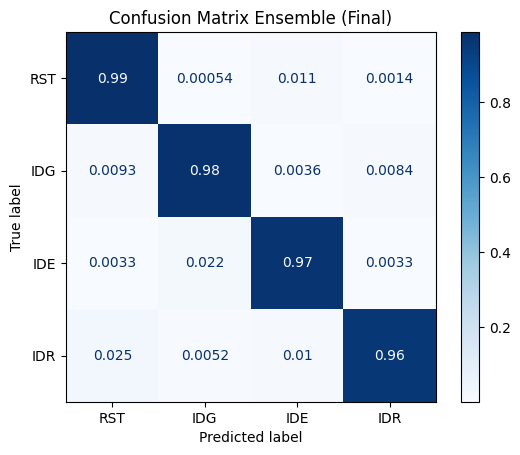

In [10]:
# ============================================================
# CELL 9 — IMBALANCE HANDLING + ENSEMBLE TUNING (PERSISTENT & AUTO-RECOVERY)
# ============================================================
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                              classification_report, ConfusionMatrixDisplay)
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
from pathlib import Path

# ─── EMERGENCY PATH RECOVERY ────────────────────────────────
if 'OUTPUT_DIR' not in globals():
    print("[RECOVERY] Mendefinisikan ulang path direktori...")
    BASE_DIR    = Path("/content/drive/MyDrive/Creativity-Dataset/")
    OUTPUT_DIR  = BASE_DIR / "output"
    FEATURE_CACHE_DIR = BASE_DIR / "cache" / "features"
    DATASET_MODE = "secondary"
    RANDOM_STATE = 42
    TARGET_LABELS = ["RST", "IDG", "IDE", "IDR"]
    CACHE_VERSION = f"v7_feature_schema_subject_stats__{DATASET_MODE}"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PARAM_CACHE_PATH = OUTPUT_DIR / f"best_params_ensemble__{DATASET_MODE}.joblib"
EVAL_CACHE_PATH = OUTPUT_DIR / f"ensemble_comparison_results__{DATASET_MODE}.csv"
FORCE_REBUILD_TUNING = False

N_ITER_SEARCH = 40
SEARCH_CV     = 5
EVAL_REPEATS  = 3

# ─── 0. AUTO-RECOVERY LOGIC (Handling Disconnects) ──────────────────────────
if 'feature_tables' not in globals() or not feature_tables:
    print("[RECOVERY] RAM kosong. Mencari data fitur di Google Drive...")
    feature_tables = {}
    cache_files = list(FEATURE_CACHE_DIR.glob(f"*{CACHE_VERSION}*.pkl"))

    if not cache_files:
        print(" [!] Gagal Recovery: File cache tidak ditemukan di Drive. Silakan jalankan Cell 1-7.")
    else:
        for cf in cache_files:
            try:
                df_temp = pd.read_pickle(cf)
                feature_tables[cf.stem] = df_temp
                print(f" [OK] Berhasil memuat: {cf.name}")
            except Exception as e:
                print(f" [!] Gagal memuat {cf.name}: {e}")

        if 'BEST_CONFIG_ID' not in globals() and feature_tables:
            BEST_CONFIG_ID = list(feature_tables.keys())[0]
            print(f" [!] BEST_CONFIG_ID diatur ulang otomatis ke: {BEST_CONFIG_ID}")

# ─── 1. Tambah derived features ──────────────────────────────────────────────
print(f"Target 4 kelas: {TARGET_LABELS}")
enriched_tables = {}
feature_columns_by_config = {}

for ident, df in feature_tables.items():
    enriched_tables[ident], derived_cols = add_derived_features(df)
    feature_columns_by_config[ident] = get_model_feature_columns(enriched_tables[ident])

print(f"Fitur derived : {len(derived_cols)}")

# ─── 2. Hyperparameter tuning (With Loading Logic) ──────────────────────────
tune_df   = enriched_tables[BEST_CONFIG_ID]
tune_cols = feature_columns_by_config[BEST_CONFIG_ID]
X_tune    = tune_df[tune_cols].fillna(0).values
y_tune    = tune_df["label"].values
g_tune    = tune_df["group_id"].values

if PARAM_CACHE_PATH.exists() and not FORCE_REBUILD_TUNING:
    print(f"\n[LOAD] Memuat parameter terbaik dari Drive: {PARAM_CACHE_PATH}")
    FINAL_PARAMS = joblib.load(PARAM_CACHE_PATH)
else:
    print(f"\n[RUN] Memulai tuning {N_ITER_SEARCH} iterasi (estimasi waktu lama)... ")
    tune_cv = StratifiedKFold(n_splits=SEARCH_CV, shuffle=True, random_state=RANDOM_STATE)

    param_dist = {
        "select__k":                    [96, 128, 160, 200, min(250, len(tune_cols))],
        "ensemble__svm__C":             [1, 5, 10, 20, 50],
        "ensemble__svm__gamma":         ["scale", "auto", 0.01, 0.001],
        "ensemble__rf__n_estimators":   [200, 300, 500],
        "ensemble__rf__max_depth":      [10, 20, None],
        "ensemble__knn__n_neighbors":   [3, 5, 7, 9],
        "ensemble__knn__weights":       ["distance", "uniform"],
        "ensemble__xgb__n_estimators":  [100, 200, 300],
        "ensemble__xgb__max_depth":     [4, 6, 8],
        "ensemble__xgb__learning_rate": [0.05, 0.1, 0.2],
    }

    base_pipeline = make_ensemble(10, "scale", 300, 6, 5, "distance",
                                   128, len(tune_cols))
    base_pipeline.steps[0] = ('adasyn', RandomOverSampler(random_state=RANDOM_STATE))

    search = RandomizedSearchCV(
        base_pipeline, param_distributions=param_dist,
        n_iter=N_ITER_SEARCH, cv=tune_cv,
        scoring="balanced_accuracy", random_state=RANDOM_STATE,
        n_jobs=-1, refit=False, verbose=1
    )
    search.fit(X_tune, y_tune)
    FINAL_PARAMS = search.best_params_
    joblib.dump(FINAL_PARAMS, PARAM_CACHE_PATH)
    print(f"DONE! Parameter disimpan ke {PARAM_CACHE_PATH}")

print("Best params   :", FINAL_PARAMS)

# ─── 3. Evaluasi akhir ───────────────────────────────────────────────────────
def robust_fit(pipeline, X, y):
    try:
        min_samples = pd.Series(y).value_counts().min()
        n_neighbors = min(3, max(1, min_samples - 1))
        pipeline.set_params(adasyn__n_neighbors=n_neighbors)
        return pipeline.fit(X, y)
    except Exception:
        steps = list(pipeline.steps)
        steps[0] = ('oversample', RandomOverSampler(random_state=RANDOM_STATE))
        from imblearn.pipeline import Pipeline as ImbPipeline
        return ImbPipeline(steps).fit(X, y)

comparison_rows = []
print(f"\nEvaluasi model ensemble pada semua konfigurasi...")

for ident, df in enriched_tables.items():
    cols = feature_columns_by_config[ident]
    X, y, groups = df[cols].fillna(0).values, df["label"].values, df["group_id"].values

    scores, all_pred, all_true = [], [], []
    for tr, te in cv_splits(y, groups, n_splits=5, n_repeats=EVAL_REPEATS):
        pipe = make_ensemble(
            svc_C=FINAL_PARAMS["ensemble__svm__C"], svc_gamma=FINAL_PARAMS["ensemble__svm__gamma"],
            rf_n=FINAL_PARAMS["ensemble__rf__n_estimators"], rf_depth=FINAL_PARAMS["ensemble__rf__max_depth"],
            knn_k=FINAL_PARAMS["ensemble__knn__n_neighbors"], knn_w=FINAL_PARAMS["ensemble__knn__weights"],
            select_k=FINAL_PARAMS["select__k"], n_features_available=len(cols),
            xgb_n=FINAL_PARAMS["ensemble__xgb__n_estimators"],
            xgb_depth=FINAL_PARAMS["ensemble__xgb__max_depth"],
            xgb_lr=FINAL_PARAMS["ensemble__xgb__learning_rate"]
        )
        pipe = robust_fit(pipe, X[tr], y[tr])
        pred = pipe.predict(X[te])
        scores.append(balanced_accuracy_score(y[te], pred))
        all_pred.extend(pred); all_true.extend(y[te])

    res = {
        "config_id": ident, "n_features": len(cols),
        "mean_bal_acc": np.mean(scores), "std_bal_acc": np.std(scores),
        "macro_f1": f1_score(all_true, all_pred, average="macro", zero_division=0),
    }
    comparison_rows.append(res)
    print(f"{ident[:50]:50s} -> bal_acc={res['mean_bal_acc']:.4f}")

comparison_df = pd.DataFrame(comparison_rows).sort_values("mean_bal_acc", ascending=False)
comparison_df.to_csv(EVAL_CACHE_PATH, index=False)
display(comparison_df)

FINAL_CONFIG_ID = comparison_df.iloc[0]["config_id"]
FINAL_COLS = feature_columns_by_config[FINAL_CONFIG_ID]
final_feature_df = enriched_tables[FINAL_CONFIG_ID].copy()

# ─── 4. Confusion Matrix Final ───────────────────────────────────────────────
print(f"\nLaporan Akhir: {FINAL_CONFIG_ID}")
X_eval, y_eval, g_eval = final_feature_df[FINAL_COLS].fillna(0).values, final_feature_df["label"].values, final_feature_df["group_id"].values
all_pred, all_true = [], []
for tr, te in cv_splits(y_eval, g_eval, n_splits=5, n_repeats=EVAL_REPEATS):
    p = robust_fit(make_ensemble(FINAL_PARAMS["ensemble__svm__C"], FINAL_PARAMS["ensemble__svm__gamma"], FINAL_PARAMS["ensemble__rf__n_estimators"], FINAL_PARAMS["ensemble__rf__max_depth"], FINAL_PARAMS["ensemble__knn__n_neighbors"], FINAL_PARAMS["ensemble__knn__weights"], FINAL_PARAMS["select__k"], len(FINAL_COLS), FINAL_PARAMS["ensemble__xgb__n_estimators"], FINAL_PARAMS["ensemble__xgb__max_depth"], FINAL_PARAMS["ensemble__xgb__learning_rate"]), X_eval[tr], y_eval[tr])
    all_pred.extend(p.predict(X_eval[te])); all_true.extend(y_eval[te])

ConfusionMatrixDisplay.from_predictions(all_true, all_pred, labels=TARGET_LABELS, normalize="true", cmap="Blues")
plt.title("Confusion Matrix Ensemble (Final)")
plt.show()

EVALUASI INDIVIDUAL BASE CLASSIFIER
Dataset       : epoch_4.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v7_feature_schema_subject_stats__primary
Jumlah epoch  : 5386
Jumlah fitur  : 432  (select_k=250)
  [RandomForest] ...   cv_splits fallback: 5 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.9721
  [SVM RBF] ...   cv_splits fallback: 5 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.7290
  [KNN] ...   cv_splits fallback: 5 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.9345
  [XGBoost] ...   cv_splits fallback: 5 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.9817
  [Ensemble] ...   cv_splits fallback: 5 grup < 10   RepeatedStratifiedKFold(n_repeats=3)
Bal.Acc=0.9742


,Classifier,Balanced Accuracy,Macro F1
3,XGBoost,0.981696,0.981773
4,Ensemble,0.974225,0.974304
0,RandomForest,0.972128,0.972093
2,KNN,0.934515,0.934454
1,SVM RBF,0.729035,0.726594


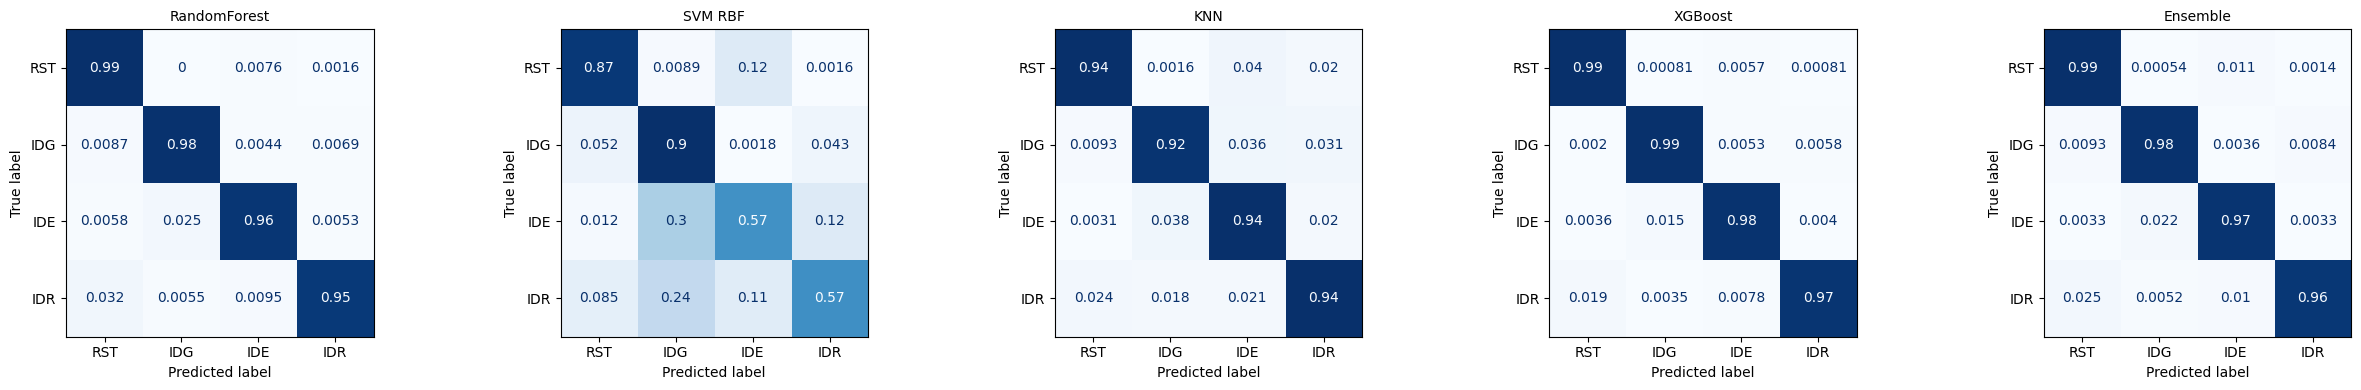

Tabel perbandingan disimpan: /content/drive/MyDrive/Creativity-Dataset/output/individual_classifier_comparison__primary.csv


In [11]:
# ============================================================
# CELL 10 — EVALUASI PER CLASSIFIER INDIVIDUAL (WITH RECOVERY)
# ============================================================
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from imblearn.over_sampling import ADASYN, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, ConfusionMatrixDisplay)

# ─── EMERGENCY RECOVERY ─────────────────────────────────────
if 'OUTPUT_DIR' not in globals():
    print("[RECOVERY] Mendefinisikan ulang konfig dasar...")
    BASE_DIR = Path("/content/drive/MyDrive/Creativity-Dataset/")
    OUTPUT_DIR = BASE_DIR / "output"
    DATASET_MODE = "secondary"
    RANDOM_STATE = 42
    TARGET_LABELS = ["RST", "IDG", "IDE", "IDR"]

if 'FINAL_PARAMS' not in globals():
    param_path = OUTPUT_DIR / f"best_params_ensemble__{DATASET_MODE}.joblib"
    if param_path.exists():
        print(f"[RECOVERY] Memuat kembali FINAL_PARAMS dari {param_path.name}")
        FINAL_PARAMS = joblib.load(param_path)
    else:
        print("[!] Gagal Recovery: FINAL_PARAMS tidak ditemukan. Jalankan Cell 9.")

if 'final_feature_df' not in globals():
    eval_cache = OUTPUT_DIR / f"ensemble_comparison_results__{DATASET_MODE}.csv"
    if eval_cache.exists():
        print("[RECOVERY] Mendeteksi FINAL_CONFIG_ID dari cache evaluasi...")
        comp_df = pd.read_csv(eval_cache)
        FINAL_CONFIG_ID = comp_df.iloc[0]["config_id"]
        if 'enriched_tables' in globals() and FINAL_CONFIG_ID in enriched_tables:
             final_feature_df = enriched_tables[FINAL_CONFIG_ID]
             FINAL_COLS = feature_columns_by_config[FINAL_CONFIG_ID]
        else:
             print("[!] Gagal Recovery: Data fitur (enriched_tables) hilang dari RAM. Jalankan Cell 9.")

print("=" * 70)
print("EVALUASI INDIVIDUAL BASE CLASSIFIER")
print("=" * 70)

_X   = final_feature_df[FINAL_COLS].fillna(0).values
_y   = final_feature_df["label"].values
_grp = final_feature_df["group_id"].values
_k   = min(FINAL_PARAMS["select__k"], len(FINAL_COLS))

le = LabelEncoder()
le.fit(TARGET_LABELS)

print(f"Dataset       : {FINAL_CONFIG_ID}")
print(f"Jumlah epoch  : {len(_y)}")
print(f"Jumlah fitur  : {len(FINAL_COLS)}  (select_k={_k})")

def _make_individual(clf, k):
    return ImbPipeline([
        ("adasyn",  ADASYN(sampling_strategy="auto", random_state=RANDOM_STATE, n_neighbors=5)),
        ("select",  SelectKBest(score_func=f_classif, k=min(k, len(FINAL_COLS)))),
        ("clf",     clf),
    ])

def _make_individual_safe(clf, k):
    return ImbPipeline([
        ("adasyn",  RandomOverSampler(sampling_strategy="auto", random_state=RANDOM_STATE)),
        ("select",  SelectKBest(score_func=f_classif, k=min(k, len(FINAL_COLS)))),
        ("clf",     clf),
    ])

INDIVIDUAL_CLASSIFIERS = {
    "RandomForest": RandomForestClassifier(
        n_estimators = FINAL_PARAMS["ensemble__rf__n_estimators"],
        max_depth    = FINAL_PARAMS["ensemble__rf__max_depth"],
        class_weight = "balanced_subsample",
        random_state = RANDOM_STATE, n_jobs = -1,
    ),
    "SVM RBF": SVC(
        C            = FINAL_PARAMS["ensemble__svm__C"],
        gamma        = FINAL_PARAMS["ensemble__svm__gamma"],
        kernel       = "rbf", class_weight = "balanced",
        probability  = False, random_state = RANDOM_STATE,
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors  = FINAL_PARAMS["ensemble__knn__n_neighbors"],
        weights      = FINAL_PARAMS["ensemble__knn__weights"], n_jobs = -1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators   = FINAL_PARAMS["ensemble__xgb__n_estimators"],
        max_depth      = FINAL_PARAMS["ensemble__xgb__max_depth"],
        learning_rate  = FINAL_PARAMS["ensemble__xgb__learning_rate"],
        use_label_encoder = False, eval_metric = "mlogloss",
        random_state   = RANDOM_STATE, n_jobs = -1, verbosity = 0,
    ),
    "Ensemble": make_ensemble(
        svc_C = FINAL_PARAMS["ensemble__svm__C"], svc_gamma = FINAL_PARAMS["ensemble__svm__gamma"],
        rf_n = FINAL_PARAMS["ensemble__rf__n_estimators"], rf_depth = FINAL_PARAMS["ensemble__rf__max_depth"],
        knn_k = FINAL_PARAMS["ensemble__knn__n_neighbors"], knn_w = FINAL_PARAMS["ensemble__knn__weights"],
        select_k = _k, n_features_available = len(FINAL_COLS),
        xgb_n = FINAL_PARAMS["ensemble__xgb__n_estimators"], xgb_depth = FINAL_PARAMS["ensemble__xgb__max_depth"], xgb_lr = FINAL_PARAMS["ensemble__xgb__learning_rate"],
    ),
}

indiv_results = []
indiv_preds   = {}

for clf_name, clf_obj in INDIVIDUAL_CLASSIFIERS.items():
    print(f"  [{clf_name}] ...", end=" ", flush=True)
    fold_bal = []; yt_all = []; yp_all = []
    is_ensemble = clf_name == "Ensemble"
    is_xgb = clf_name == "XGBoost"

    for tr, te in cv_splits(_y, _grp, n_splits=5, n_repeats=EVAL_REPEATS):
        X_tr, X_te = _X[tr], _X[te]
        y_tr = le.transform(_y[tr]) if is_xgb else _y[tr]
        y_te = le.transform(_y[te]) if is_xgb else _y[te]

        pipe = clf_obj if is_ensemble else _make_individual(clf_obj, _k)
        try:
            pipe.fit(X_tr, y_tr)
        except Exception:
            pipe = _make_individual_safe(clf_obj, _k)
            pipe.fit(X_tr, y_tr)

        pred = pipe.predict(X_te)
        if is_xgb:
            yt_all.extend(le.inverse_transform(y_te)); yp_all.extend(le.inverse_transform(pred))
            fold_bal.append(balanced_accuracy_score(le.inverse_transform(y_te), le.inverse_transform(pred)))
        else:
            yt_all.extend(y_te); yp_all.extend(pred)
            fold_bal.append(balanced_accuracy_score(y_te, pred))

    row = {"Classifier": clf_name, "Balanced Accuracy": np.mean(fold_bal), "Macro F1": f1_score(yt_all, yp_all, average="macro", zero_division=0)}
    indiv_results.append(row); indiv_preds[clf_name] = (np.array(yt_all), np.array(yp_all))
    print(f"Bal.Acc={row['Balanced Accuracy']:.4f}")

indiv_df = pd.DataFrame(indiv_results).sort_values("Balanced Accuracy", ascending=False)
display(indiv_df)

# ─── VISUALISASI CONFUSION MATRIX ───────────────────────────
n_clf = len(indiv_preds)
fig, axes = plt.subplots(1, n_clf, figsize=(5 * n_clf, 4))
if n_clf == 1: axes = [axes]
for ax, (name, (yt, yp)) in zip(axes, indiv_preds.items()):
    ConfusionMatrixDisplay.from_predictions(yt, yp, labels=TARGET_LABELS, normalize="true", cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

# ─── SIMPAN HASIL ───────────────────────────────────────────
out_path = OUTPUT_DIR / f"individual_classifier_comparison__{DATASET_MODE}.csv"
indiv_df.to_csv(out_path, index=False)
print(f"Tabel perbandingan disimpan: {out_path}")

In [12]:
# ============================================================
# CELL 11 — FIT FINAL MODEL (WITH RECOVERY)
# ============================================================
if 'final_feature_df' not in globals():
    print("[RECOVERY] Mengulangi deteksi data final...")
    # Fallback jika RAM bersih: baca kembali dari cache
    eval_cache = OUTPUT_DIR / f"ensemble_comparison_results__{DATASET_MODE}.csv"
    if eval_cache.exists():
        comp_df = pd.read_csv(eval_cache)
        FINAL_CONFIG_ID = comp_df.iloc[0]["config_id"]
        # Dataframe harus dimuat di Cell 9, jika hilang total tetap butuh Cell 9
        if 'enriched_tables' in globals():
            final_feature_df = enriched_tables[FINAL_CONFIG_ID]
            FINAL_COLS = feature_columns_by_config[FINAL_CONFIG_ID]

final_training_df = final_feature_df.copy()
X_final = final_training_df[FINAL_COLS].fillna(0).values
y_final = final_training_df["label"].values

final_pipeline = make_ensemble(
    FINAL_PARAMS["ensemble__svm__C"], FINAL_PARAMS["ensemble__svm__gamma"],
    FINAL_PARAMS["ensemble__rf__n_estimators"], FINAL_PARAMS["ensemble__rf__max_depth"],
    FINAL_PARAMS["ensemble__knn__n_neighbors"], FINAL_PARAMS["ensemble__knn__weights"],
    FINAL_PARAMS["select__k"], len(FINAL_COLS),
    FINAL_PARAMS["ensemble__xgb__n_estimators"], FINAL_PARAMS["ensemble__xgb__max_depth"], FINAL_PARAMS["ensemble__xgb__learning_rate"]
)

print(f"Melatih model final: {FINAL_CONFIG_ID} ...")
final_pipeline = robust_fit(final_pipeline, X_final, y_final)

run_label = DATASET_MODE
model_path = OUTPUT_DIR / f"ensemble_model__{run_label}.joblib"
joblib.dump({"model": final_pipeline, "params": FINAL_PARAMS, "cols": FINAL_COLS}, model_path)
print("MODEL TERSIMPAN:", model_path)

Melatih model final: epoch_4.0s__overlap_0.75__trim_2.0s__spectral_True__4class__v7_feature_schema_subject_stats__primary ...
MODEL TERSIMPAN: /content/drive/MyDrive/Creativity-Dataset/output/ensemble_model__primary.joblib


In [13]:
# ============================================================
# CELL 12 — EXTERNAL VALIDATION (SECONDARY -> PRIMARY)
# ============================================================
if DATASET_MODE != "external_validation":
    print("Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.")
else:
    ext_df = enriched_tables[FINAL_CONFIG_ID]
    ext_df = ext_df[ext_df["source"] == "primary"].copy()
    if ext_df.empty:
        raise ValueError("Dataset primer kosong. Pastikan file tersedia di folder Primary-raw.")
    X_ext, y_ext = ext_df[FINAL_COLS].values, ext_df["label"].astype(str).values
    ext_preds = final_pipeline.predict(X_ext)
    print("EXTERNAL VALIDATION: Train (Concordia) -> Test (OpenBCI)")
    print(f"Accuracy: {accuracy_score(y_ext, ext_preds):.4f} | "
          f"BalAcc: {balanced_accuracy_score(y_ext, ext_preds):.4f} | "
          f"Macro-F1: {f1_score(y_ext, ext_preds, average='macro', zero_division=0):.4f}")
    # FIX: LABELS tidak pernah didefinisikan di notebook manapun -> ganti ke TARGET_LABELS
    print("\nCLASSIFICATION REPORT:\n", classification_report(y_ext, ext_preds, labels=TARGET_LABELS, zero_division=0))
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(y_ext, ext_preds, labels=TARGET_LABELS, normalize="true", values_format=".2f", ax=ax)
    ax.set_title("External Validation: Train Secondary -> Test Primary")
    plt.tight_layout(); plt.show()
    ext_res_df = ext_df[["source", "subject_id", "record_id", "label", "epoch_start"]].copy()
    ext_res_df["predicted_label"] = ext_preds
    ext_res_df.to_csv(OUTPUT_DIR / "external_validation_predictions.csv", index=False)

Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.


Unit Analisis: EPOCH
Jumlah entri per kondisi: {'IDG': 1500, 'IDE': 1496, 'RST': 1232, 'IDR': 1158}

CATATAN: Statistik epoch hanya exploratory/descriptive.
Epoch overlap tidak dapat diperlakukan sebagai sampel independen populasi.


delta                 theta                 alpha                \
         mean     std count    mean     std count    mean     std count   
label                                                                     
IDE    0.0303  0.0822  1496  0.0223  0.0306  1496  0.0362  0.0411  1496   
IDG    0.0838  0.2087  1500  0.0092  0.0229  1500  0.0082  0.0172  1500   
IDR    0.0824  0.1970  1158  0.0273  0.0302  1158  0.0450  0.0597  1158   
RST    0.3145  0.3207  1232  0.0458  0.0387  1232  0.0339  0.0503  1232   

         beta                 gamma                
         mean     std count    mean     std count  
label                                              
IDE    0.8405  0.1738  1496  0.0564  0.0720  1496  
IDG    0.8727  0.2297  1500  0.0204  0.0283  1500  
IDR    0.7455  0.2493  1158  0.0809  0.0870  1158  
RST    0.5417  0.3207  1232  0.0309  0.0529  1232


Uji Normalitas:


,band,condition,n_epoch,shapiro_w,shapiro_p,normal_at_alpha_0_05
0,delta,IDG,1500,0.456203,2.648072e-55,False
1,delta,IDE,1496,0.337598,1.102611e-58,False
2,delta,IDR,1158,0.443466,1.006009e-50,False
3,delta,RST,1232,0.820964,5.909191e-35,False
4,theta,IDG,1500,0.410314,1.059977e-56,False
5,theta,IDE,1496,0.742472,3.273305e-43,False
6,theta,IDR,1158,0.827787,1.558152e-33,False
7,theta,RST,1232,0.847803,8.183579e-33,False
8,alpha,IDG,1500,0.484201,2.114215e-54,False
9,alpha,IDE,1496,0.829647,3.275759e-37,False



Uji Statistik Pairwise + Bonferroni:


,band,condition_a,condition_b,n_a,n_b,test,statistic,p_uncorrected,effect_metric,effect_size,mean_a,mean_b,interpretation,bonferroni_family_size,p_bonferroni,significant_bonferroni
8,theta,IDG,RST,1500,1232,Mann-Whitney U (Exploratory),187710.0,4.438527e-282,Rank-biserial r,-0.796851,0.009151,0.045833,Exploratory/descriptive; epoch overlap is not ...,30,1.331558e-280,True
4,delta,IDE,RST,1496,1232,Mann-Whitney U (Exploratory),235484.0,3.445630e-246,Rank-biserial r,-0.744466,0.030310,0.314469,Exploratory/descriptive; epoch overlap is not ...,30,1.033689e-244,True
2,delta,IDG,RST,1500,1232,Mann-Whitney U (Exploratory),255383.0,5.508989e-233,Rank-biserial r,-0.723611,0.083837,0.314469,Exploratory/descriptive; epoch overlap is not ...,30,1.652697e-231,True
20,beta,IDG,RST,1500,1232,Mann-Whitney U (Exploratory),1564537.0,5.320275e-214,Rank-biserial r,0.693222,0.872676,0.541694,Exploratory/descriptive; epoch overlap is not ...,30,1.596082e-212,True
14,alpha,IDG,RST,1500,1232,Mann-Whitney U (Exploratory),289560.0,5.504380e-210,Rank-biserial r,-0.686623,0.008159,0.033901,Exploratory/descriptive; epoch overlap is not ...,30,1.651314e-208,True
22,beta,IDE,RST,1496,1232,Mann-Whitney U (Exploratory),1457478.0,4.741471e-151,Rank-biserial r,0.581575,0.840461,0.541694,Exploratory/descriptive; epoch overlap is not ...,30,1.422441e-149,True
5,delta,IDR,RST,1158,1232,Mann-Whitney U (Exploratory),279387.0,4.414261e-146,Rank-biserial r,-0.608333,0.082389,0.314469,Exploratory/descriptive; epoch overlap is not ...,30,1.324278e-144,True
13,alpha,IDG,IDR,1500,1158,Mann-Whitney U (Exploratory),387853.0,1.494697e-132,Rank-biserial r,-0.553422,0.008159,0.045043,Exploratory/descriptive; epoch overlap is not ...,30,4.484091e-131,True
7,theta,IDG,IDR,1500,1158,Mann-Whitney U (Exploratory),411074.0,3.058471e-120,Rank-biserial r,-0.526685,0.009151,0.027311,Exploratory/descriptive; epoch overlap is not ...,30,9.175414e-119,True
10,theta,IDE,RST,1496,1232,Mann-Whitney U (Exploratory),481134.0,1.220439e-102,Rank-biserial r,-0.477900,0.022278,0.045833,Exploratory/descriptive; epoch overlap is not ...,30,3.661318e-101,True


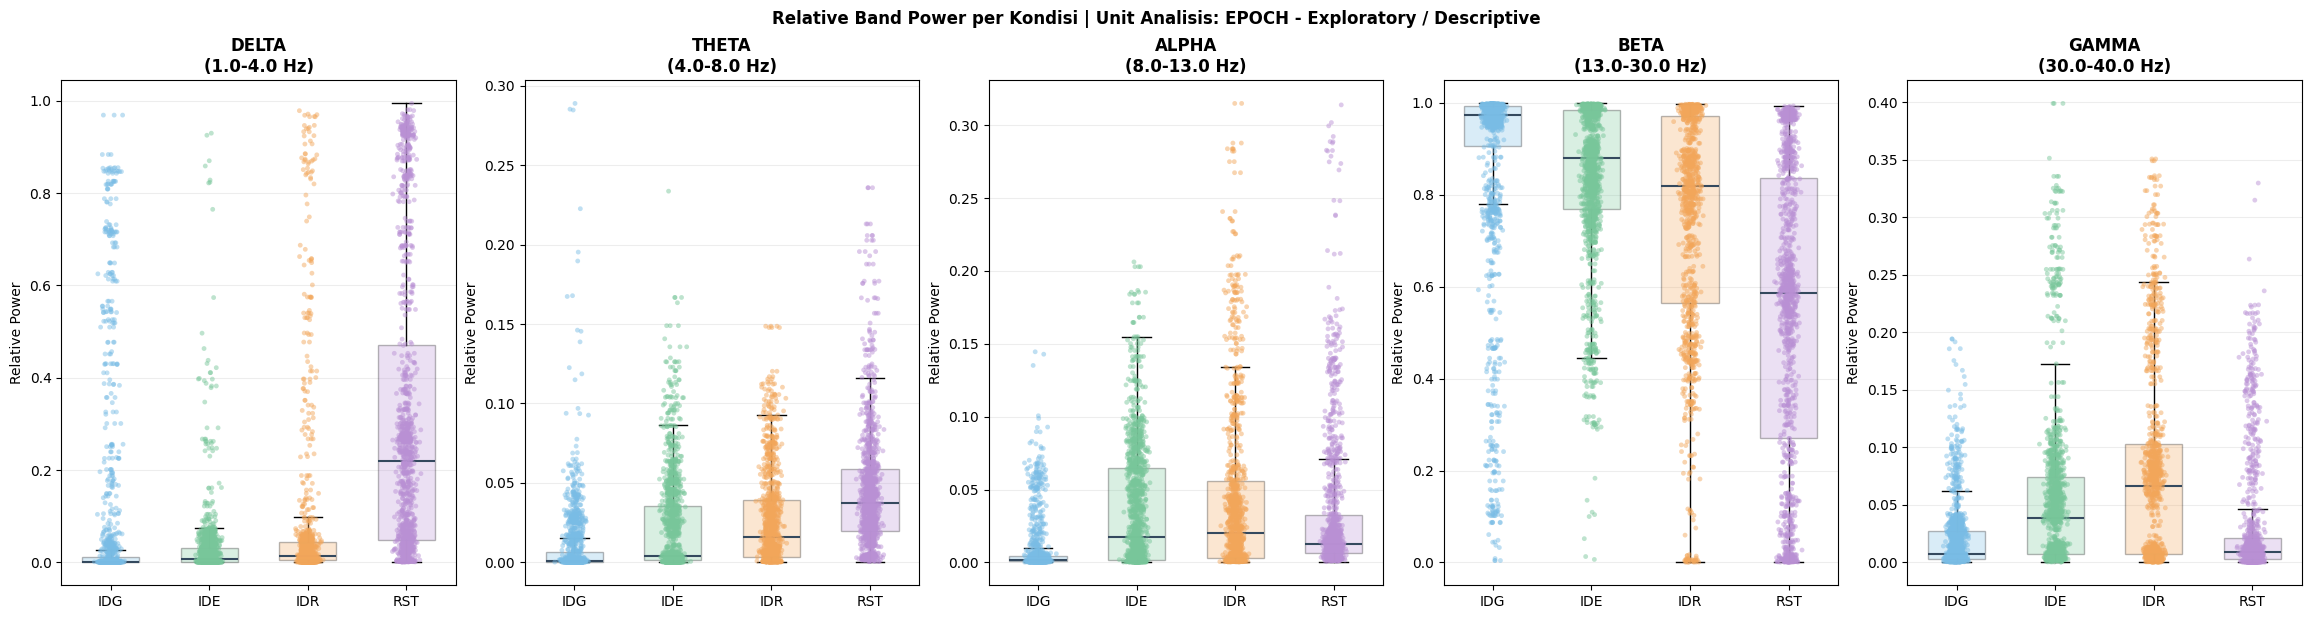


Output tersimpan di: /content/drive/MyDrive/Creativity-Dataset/output


In [14]:
# ============================================================
# CELL 13 - VISUALISASI & UJI STATISTIK UNIFIED
# ============================================================
# "epoch"   = exploratory/descriptive
# "subject" = inferential, butuh minimal 3 subjek independen

from itertools import combinations
from scipy.stats import mannwhitneyu, rankdata, shapiro, ttest_rel, wilcoxon

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UNIT_OF_ANALYSIS = "epoch"  # "epoch" atau "subject"
STAT_ALPHA = 0.05
STAT_OUTPUT_SUFFIX = f"{DATASET_MODE}_{UNIT_OF_ANALYSIS}"

STAT_LABEL_ORDER = [x for x in ["IDG", "IDE", "IDR", "RST"]
                    if x in final_feature_df["label"].unique()]

STAT_COLORS = {
    "IDG": "#79BCE5", "IDE": "#78C69A",
    "IDR": "#F2A65A", "RST": "#B990D4",
}


def build_relative_band_power_table(feature_df):
    meta_cols = ["source", "subject_id", "record_id", "label", "epoch_start", "epoch_size"]
    output = feature_df[[c for c in meta_cols if c in feature_df.columns]].copy()

    for band in FREQUENCY_BANDS:
        cols = [f"{ch}__spectral__{band}" for ch in CANONICAL_CHANNELS]
        missing = [c for c in cols if c not in feature_df.columns]

        if missing:
            raise ValueError(
                f"Fitur spectral {band} tidak ditemukan. "
                "Jalankan ulang Cell 5 dan Cell 6 versi v7."
            )

        output[band] = feature_df[cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

    band_sum = output[list(FREQUENCY_BANDS)].sum(axis=1)

    if not np.all(np.isfinite(band_sum)) or np.allclose(band_sum.to_numpy(), 0):
        raise ValueError("Relative band power tidak valid atau seluruhnya nol.")

    return output


def build_subject_band_power(epoch_df):
    return (
        epoch_df.groupby(["source", "subject_id", "label"], as_index=False)[list(FREQUENCY_BANDS)]
        .mean()
        .rename(columns={band: f"mean_{band}" for band in FREQUENCY_BANDS})
    )


def rank_biserial_from_u(u_stat, n_a, n_b):
    return np.nan if not n_a or not n_b else float((2 * u_stat / (n_a * n_b)) - 1)


def cohen_dz(values_a, values_b):
    diff = np.asarray(values_a, dtype=float) - np.asarray(values_b, dtype=float)

    if len(diff) < 2:
        return np.nan

    sd = np.std(diff, ddof=1)
    return float(np.mean(diff) / sd) if sd > 0 else 0.0


def paired_rank_biserial(values_a, values_b):
    diff = np.asarray(values_a, dtype=float) - np.asarray(values_b, dtype=float)
    diff = diff[~np.isclose(diff, 0)]

    if not len(diff):
        return 0.0

    ranks = rankdata(np.abs(diff))
    positive = ranks[diff > 0].sum()
    negative = ranks[diff < 0].sum()

    return float((positive - negative) / (positive + negative))


def add_bonferroni(stats_df):
    output = stats_df.copy()
    n_tests = output["p_uncorrected"].notna().sum()

    output["bonferroni_family_size"] = n_tests
    output["p_bonferroni"] = np.minimum(output["p_uncorrected"] * n_tests, 1.0)
    output["significant_bonferroni"] = output["p_bonferroni"] < STAT_ALPHA

    return output


def run_epoch_statistics(epoch_df):
    normality_rows, test_rows = [], []

    for band in FREQUENCY_BANDS:
        for label in STAT_LABEL_ORDER:
            values = epoch_df.loc[epoch_df["label"] == label, band].dropna().to_numpy(float)

            if len(values) >= 3:
                shapiro_w, shapiro_p = shapiro(values)
            else:
                shapiro_w, shapiro_p = np.nan, np.nan

            normality_rows.append({
                "band": band, "condition": label, "n_epoch": len(values),
                "shapiro_w": shapiro_w, "shapiro_p": shapiro_p,
                "normal_at_alpha_0_05": bool(pd.notna(shapiro_p) and shapiro_p > STAT_ALPHA),
            })

        for condition_a, condition_b in combinations(STAT_LABEL_ORDER, 2):
            values_a = epoch_df.loc[epoch_df["label"] == condition_a, band].dropna().to_numpy(float)
            values_b = epoch_df.loc[epoch_df["label"] == condition_b, band].dropna().to_numpy(float)

            if len(values_a) < 3 or len(values_b) < 3:
                statistic, p_value, effect_size = np.nan, np.nan, np.nan
                test_name, effect_metric = "Insufficient epochs", ""
            else:
                statistic, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
                test_name, effect_metric = "Mann-Whitney U (Exploratory)", "Rank-biserial r"
                effect_size = rank_biserial_from_u(statistic, len(values_a), len(values_b))

            test_rows.append({
                "band": band, "condition_a": condition_a, "condition_b": condition_b,
                "n_a": len(values_a), "n_b": len(values_b), "test": test_name,
                "statistic": statistic, "p_uncorrected": p_value,
                "effect_metric": effect_metric, "effect_size": effect_size,
                "mean_a": np.mean(values_a) if len(values_a) else np.nan,
                "mean_b": np.mean(values_b) if len(values_b) else np.nan,
                "interpretation": "Exploratory/descriptive; epoch overlap is not independent.",
            })

    return pd.DataFrame(normality_rows), pd.DataFrame(test_rows)


def run_subject_statistics(subject_df):
    normality_rows, test_rows = [], []

    for band in FREQUENCY_BANDS:
        wide = subject_df.pivot_table(
            index=["source", "subject_id"], columns="label",
            values=f"mean_{band}", aggfunc="first"
        )

        for condition_a, condition_b in combinations(STAT_LABEL_ORDER, 2):
            paired = wide.reindex(columns=[condition_a, condition_b]).dropna()
            values_a = paired[condition_a].to_numpy(float)
            values_b = paired[condition_b].to_numpy(float)
            diff, n_subjects = values_a - values_b, len(paired)

            if n_subjects >= 3:
                shapiro_w, shapiro_p = shapiro(diff)
                normal_difference = shapiro_p > STAT_ALPHA
            else:
                shapiro_w, shapiro_p, normal_difference = np.nan, np.nan, np.nan

            normality_rows.append({
                "band": band, "condition_a": condition_a, "condition_b": condition_b,
                "n_independent_subjects": n_subjects, "shapiro_w_difference": shapiro_w,
                "shapiro_p_difference": shapiro_p, "normal_difference": normal_difference,
            })

            if n_subjects < 3:
                statistic, p_value, effect_size = np.nan, np.nan, np.nan
                test_name, effect_metric = "Insufficient independent subjects", ""

            elif normal_difference:
                statistic, p_value = ttest_rel(values_a, values_b, nan_policy="omit")
                test_name, effect_metric = "Paired t-test", "Cohen's dz"
                effect_size = cohen_dz(values_a, values_b)

            else:
                statistic, p_value = (
                    (0.0, 1.0) if np.allclose(diff, 0)
                    else wilcoxon(values_a, values_b, alternative="two-sided")
                )
                test_name, effect_metric = "Wilcoxon signed-rank", "Rank-biserial r"
                effect_size = paired_rank_biserial(values_a, values_b)

            test_rows.append({
                "band": band, "condition_a": condition_a, "condition_b": condition_b,
                "n_independent_subjects": n_subjects, "test": test_name,
                "statistic": statistic, "p_uncorrected": p_value,
                "effect_metric": effect_metric, "effect_size": effect_size,
                "mean_a": np.mean(values_a) if n_subjects else np.nan,
                "mean_b": np.mean(values_b) if n_subjects else np.nan,
                "interpretation": "Inferential subject-level analysis.",
            })

    return pd.DataFrame(normality_rows), pd.DataFrame(test_rows)


def plot_relative_band_power(data_df, unit="epoch"):
    fig, axes = plt.subplots(1, len(FREQUENCY_BANDS), figsize=(23, 5.8), constrained_layout=True)
    rng = np.random.default_rng(42)

    for ax, (band, (low_hz, high_hz)) in zip(axes, FREQUENCY_BANDS.items()):
        column = band if unit == "epoch" else f"mean_{band}"

        values_by_condition = [
            data_df.loc[data_df["label"] == label, column].dropna().to_numpy(float)
            for label in STAT_LABEL_ORDER
        ]

        boxplot = ax.boxplot(
            values_by_condition, labels=STAT_LABEL_ORDER, patch_artist=True,
            widths=0.58, showfliers=False,
            medianprops={"color": "#34495E", "linewidth": 1.5},
        )

        for box, label in zip(boxplot["boxes"], STAT_LABEL_ORDER):
            box.set_facecolor(STAT_COLORS[label])
            box.set_alpha(0.28)

        for pos, (label, values) in enumerate(zip(STAT_LABEL_ORDER, values_by_condition), start=1):
            if not len(values):
                continue

            jitter = rng.normal(pos, 0.045, size=len(values))

            ax.scatter(
                jitter, values, color=STAT_COLORS[label], edgecolor="none",
                alpha=0.48, s=12 if unit == "epoch" else 45, zorder=3,
            )

        ax.set_title(f"{band.upper()}\n({low_hz:.1f}-{high_hz:.1f} Hz)", fontweight="bold")
        ax.set_ylabel("Relative Power" if unit == "epoch" else "Mean Relative Power per Subject")
        ax.grid(axis="y", alpha=0.22)

    unit_text = "EPOCH - Exploratory / Descriptive" if unit == "epoch" else "SUBJECT - Inferential"

    fig.suptitle(
        f"Relative Band Power per Kondisi | Unit Analisis: {unit_text}",
        fontweight="bold", y=1.04
    )

    return fig


epoch_df = build_relative_band_power_table(final_feature_df)
subject_df = build_subject_band_power(epoch_df)

analysis_df = epoch_df if UNIT_OF_ANALYSIS == "epoch" else subject_df

if UNIT_OF_ANALYSIS == "epoch":
    normality_results_df, statistics_results_df = run_epoch_statistics(epoch_df)
else:
    normality_results_df, statistics_results_df = run_subject_statistics(subject_df)

statistics_results_df = add_bonferroni(statistics_results_df)

print(f"Unit Analisis: {UNIT_OF_ANALYSIS.upper()}")
print(f"Jumlah entri per kondisi: {analysis_df['label'].value_counts().to_dict()}")

if UNIT_OF_ANALYSIS == "epoch":
    print("\nCATATAN: Statistik epoch hanya exploratory/descriptive.")
    print("Epoch overlap tidak dapat diperlakukan sebagai sampel independen populasi.")
else:
    n_subjects = subject_df[["source", "subject_id"]].drop_duplicates().shape[0]
    print(f"\nJumlah subjek independen: {n_subjects}")

    if n_subjects < 3:
        print("CATATAN: Kurang dari 3 subjek independen. p-value dan Bonferroni akan NaN.")

display(
    analysis_df.groupby("label")[
        list(FREQUENCY_BANDS) if UNIT_OF_ANALYSIS == "epoch"
        else [f"mean_{band}" for band in FREQUENCY_BANDS]
    ].agg(["mean", "std", "count"]).round(4)
)

print("\nUji Normalitas:")
display(normality_results_df)

print("\nUji Statistik Pairwise + Bonferroni:")
display(statistics_results_df.sort_values(["p_bonferroni", "band"], na_position="last"))

fig = plot_relative_band_power(analysis_df, UNIT_OF_ANALYSIS)
figure_path = OUTPUT_DIR / f"relative_band_power_boxplot__{STAT_OUTPUT_SUFFIX}.png"

fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

epoch_df.to_csv(OUTPUT_DIR / f"relative_band_power_epoch__{DATASET_MODE}.csv", index=False)
subject_df.to_csv(OUTPUT_DIR / f"relative_band_power_subject__{DATASET_MODE}.csv", index=False)
normality_results_df.to_csv(OUTPUT_DIR / f"normality_results__{STAT_OUTPUT_SUFFIX}.csv", index=False)
statistics_results_df.to_csv(OUTPUT_DIR / f"statistics_bonferroni__{STAT_OUTPUT_SUFFIX}.csv", index=False)

print(f"\nOutput tersimpan di: {OUTPUT_DIR}")

### CELL DIAGNOSTIK: Visualisasi Preprocessing & Fitur
Sel ini digunakan untuk memverifikasi kualitas sinyal dan melihat representasi data setelah ekstraksi fitur.

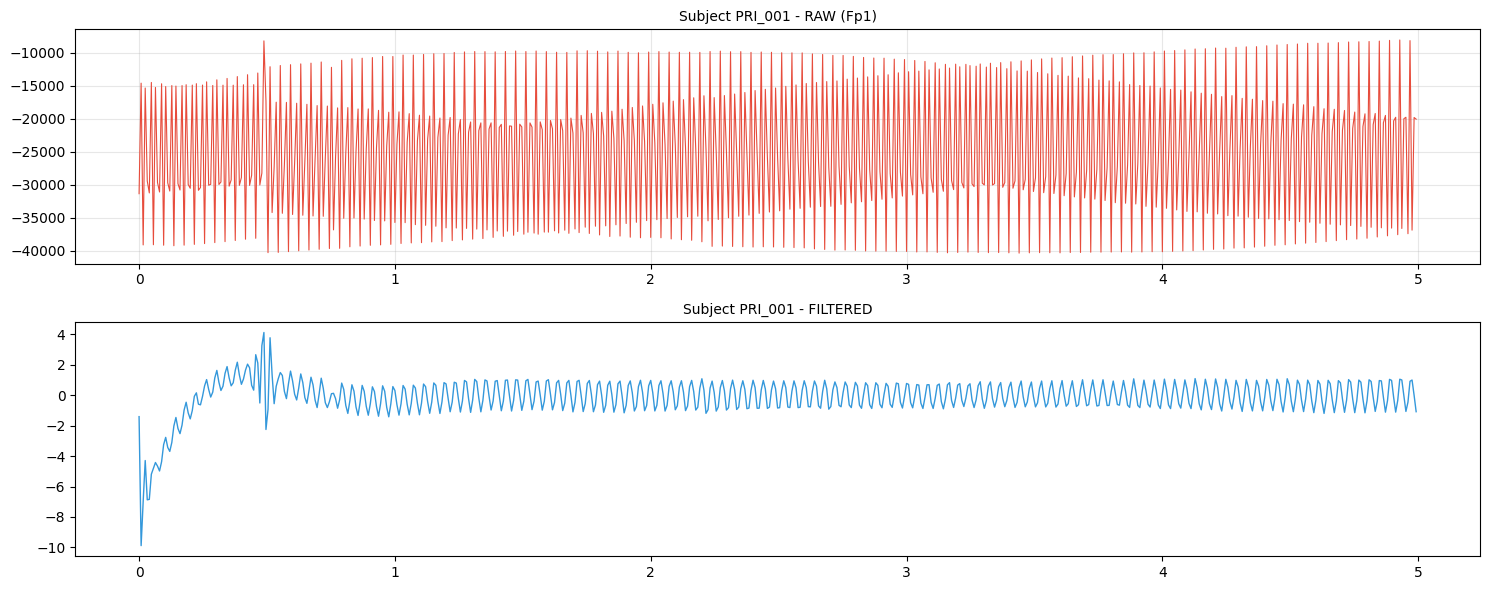

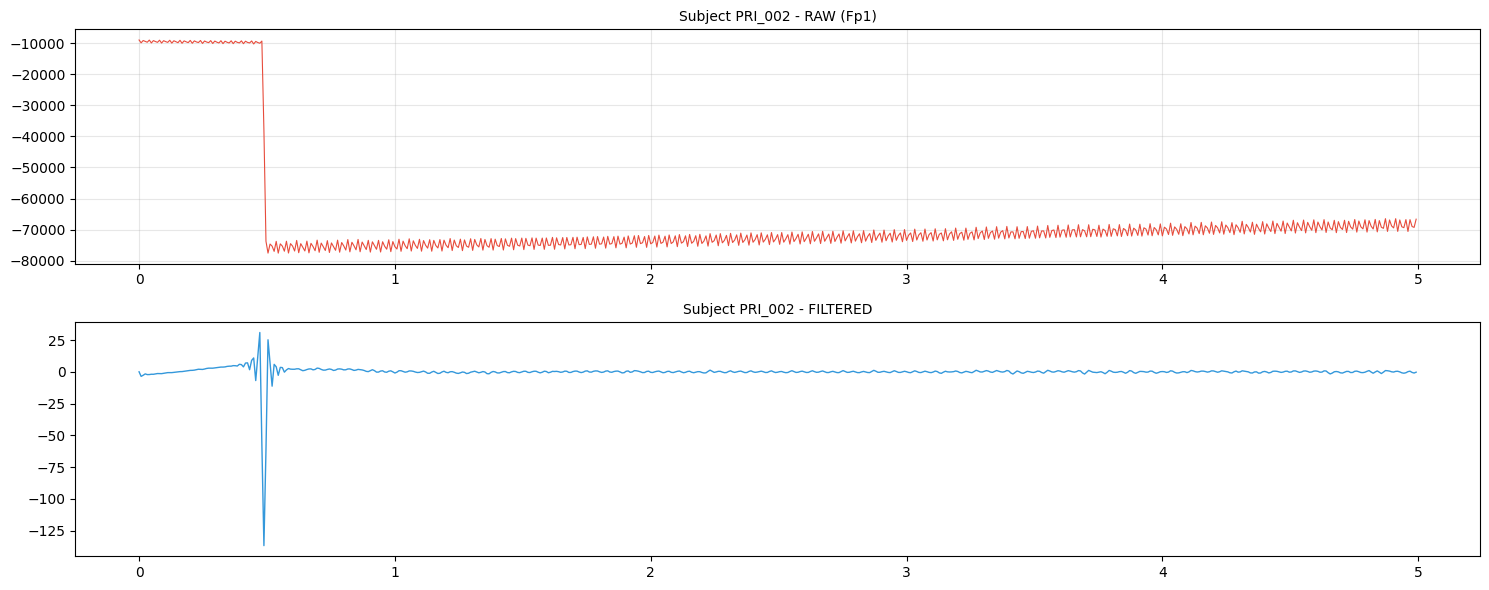

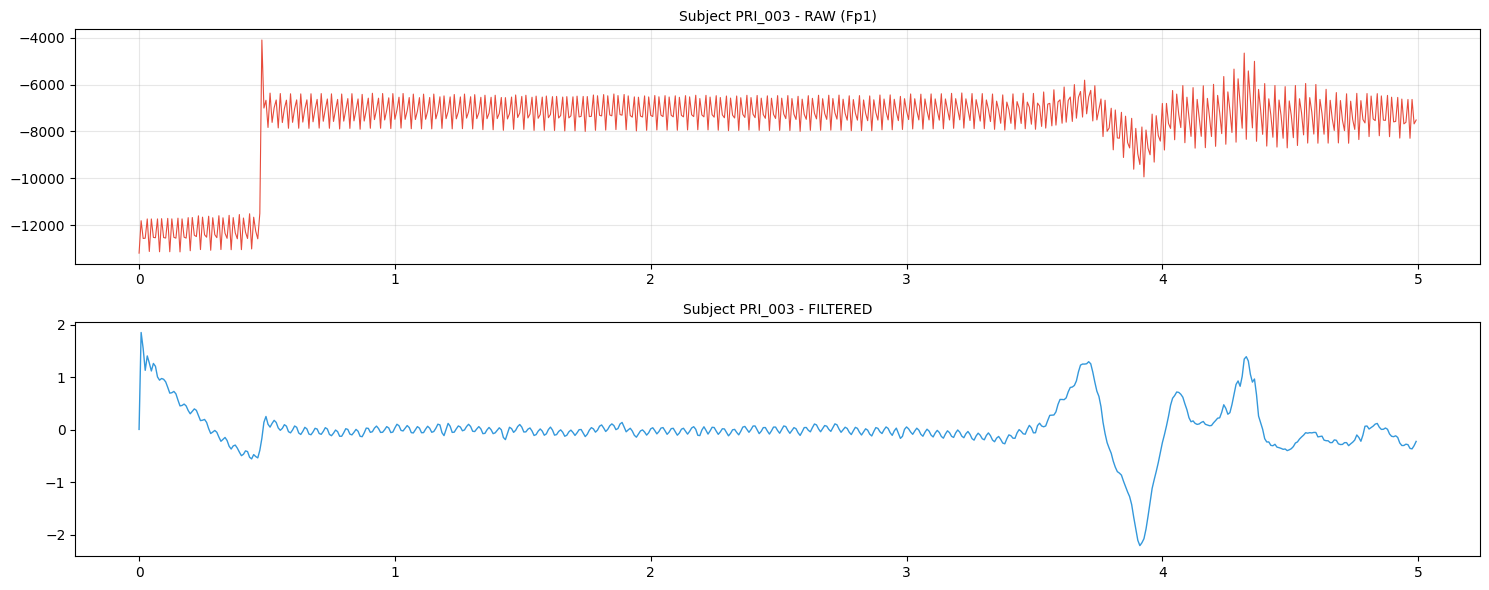

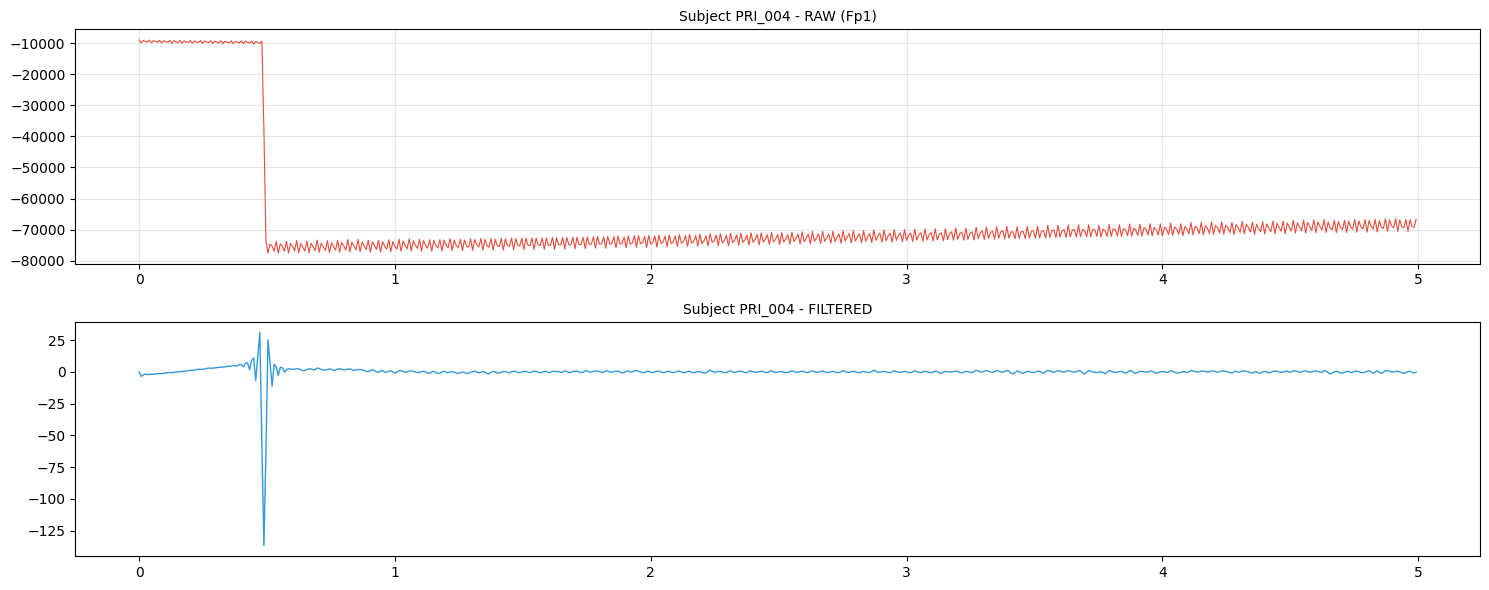

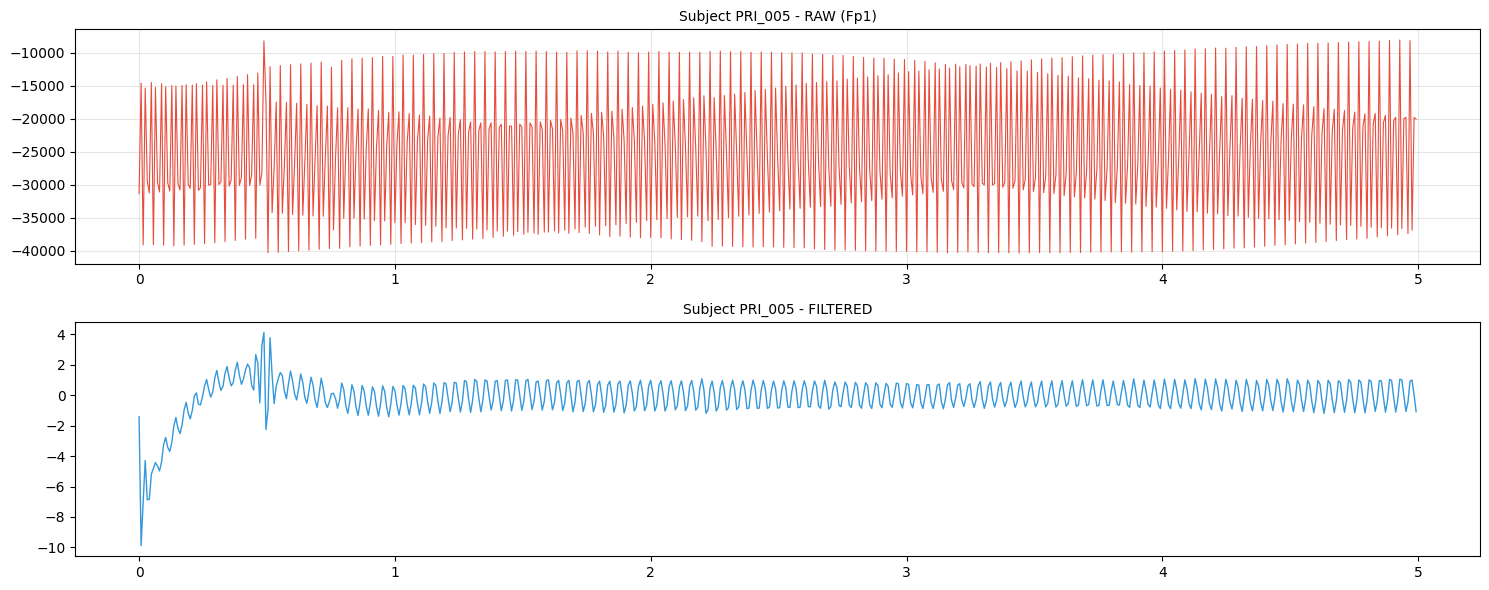

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def visualisasi_sinyal_eeg(ref_idx=0):
    if 'refs' not in globals() or len(refs) == 0:
        return

    ref = refs[ref_idx]
    raw_eeg, _ = load_record_eeg(ref)
    proc_eeg, log = preprocess_record(ref)

    ch_idx = 0
    ch_name = CANONICAL_CHANNELS[ch_idx]
    detik_tampil = 5

    t_raw = np.arange(raw_eeg.shape[1]) / ref['sfreq']
    t_proc = np.arange(proc_eeg.shape[1]) / FS_TARGET

    limit_raw = int(ref['sfreq'] * detik_tampil)
    limit_proc = int(FS_TARGET * detik_tampil)

    plt.figure(figsize=(15, 6))
    plt.subplot(2, 1, 1)
    plt.plot(t_raw[:limit_raw], raw_eeg[ch_idx, :limit_raw], color='#e74c3c', linewidth=0.8)
    plt.title(f"Subject {ref['subject_id']} - RAW ({ch_name})", fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    plt.plot(t_proc[:limit_proc], proc_eeg[ch_idx, :limit_proc], color='#3498db', linewidth=1)
    plt.title(f"Subject {ref['subject_id']} - FILTERED", fontsize=10)
    plt.tight_layout()
    plt.show()

# Menampilkan 5 Subjek Pertama
if 'refs' in globals() and len(refs) > 0:
    subject_list = []
    count = 0
    for i, r in enumerate(refs):
        if r['subject_id'] not in subject_list:
            visualisasi_sinyal_eeg(i)
            subject_list.append(r['subject_id'])
            count += 1
        if count >= 5: break
else:
    print("Silakan jalankan Cell 3 terlebih dahulu.")

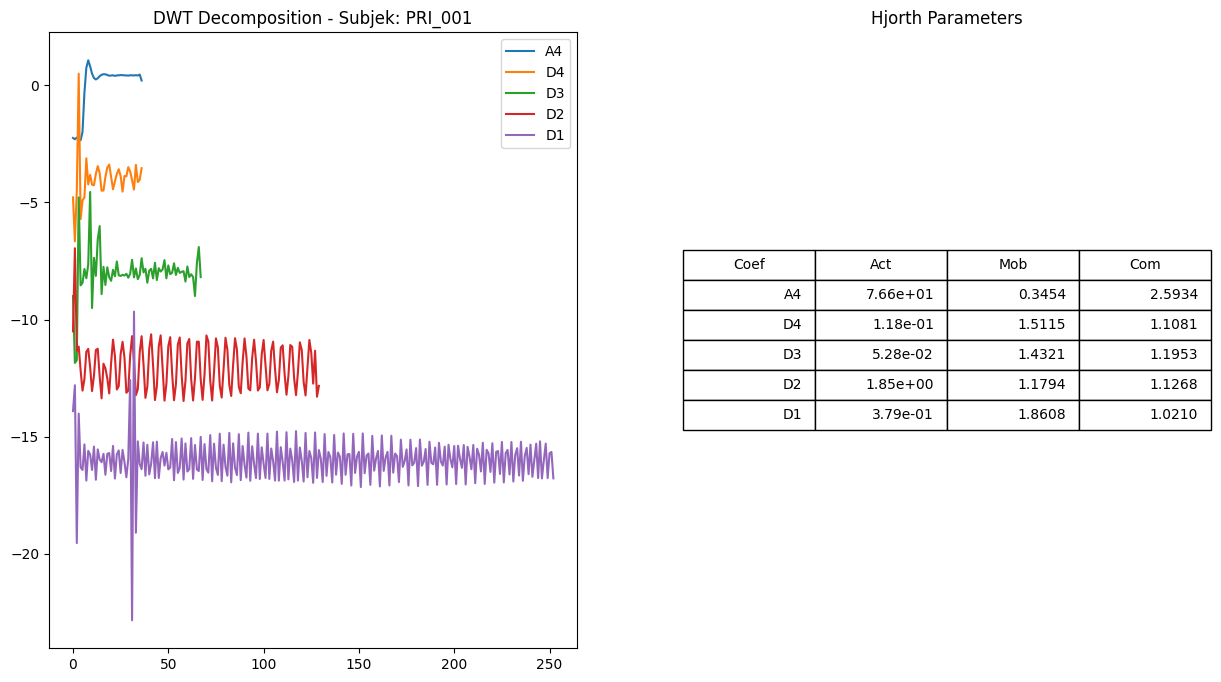

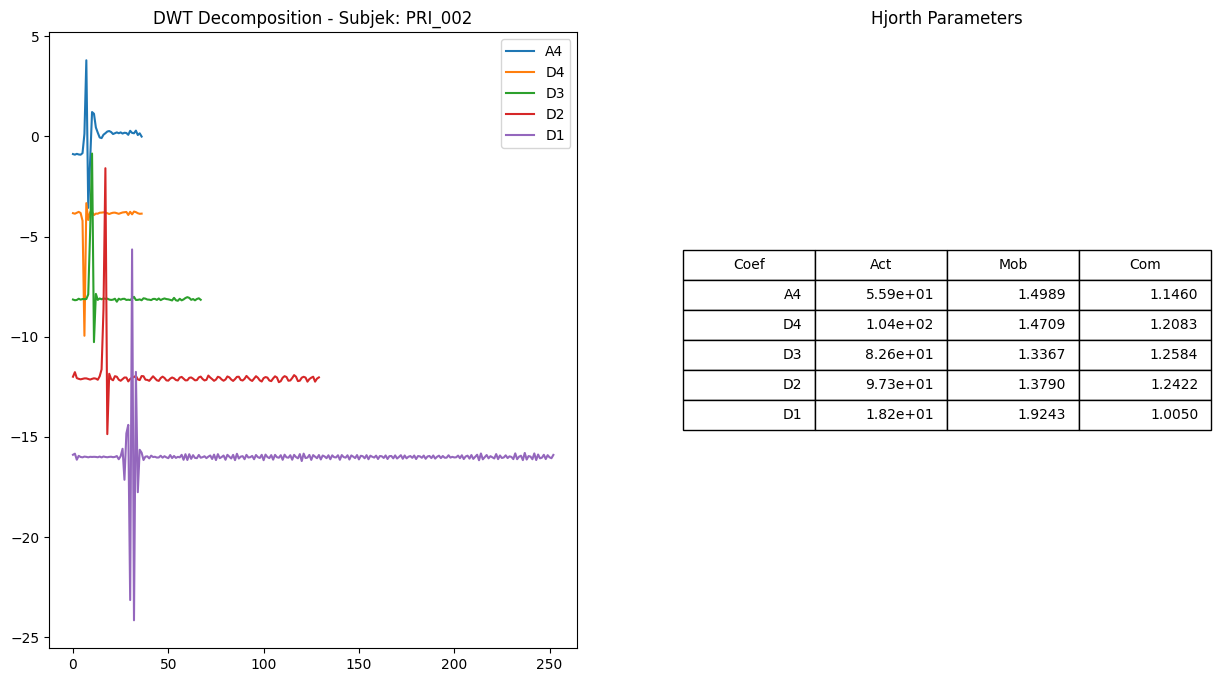

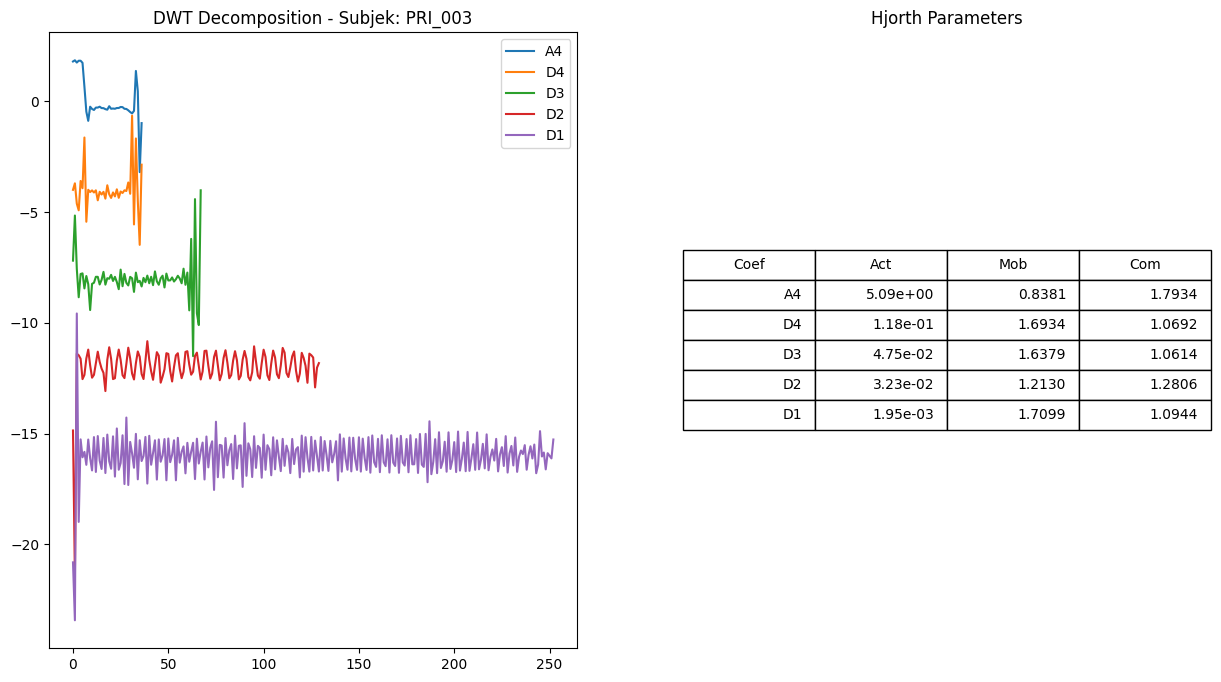

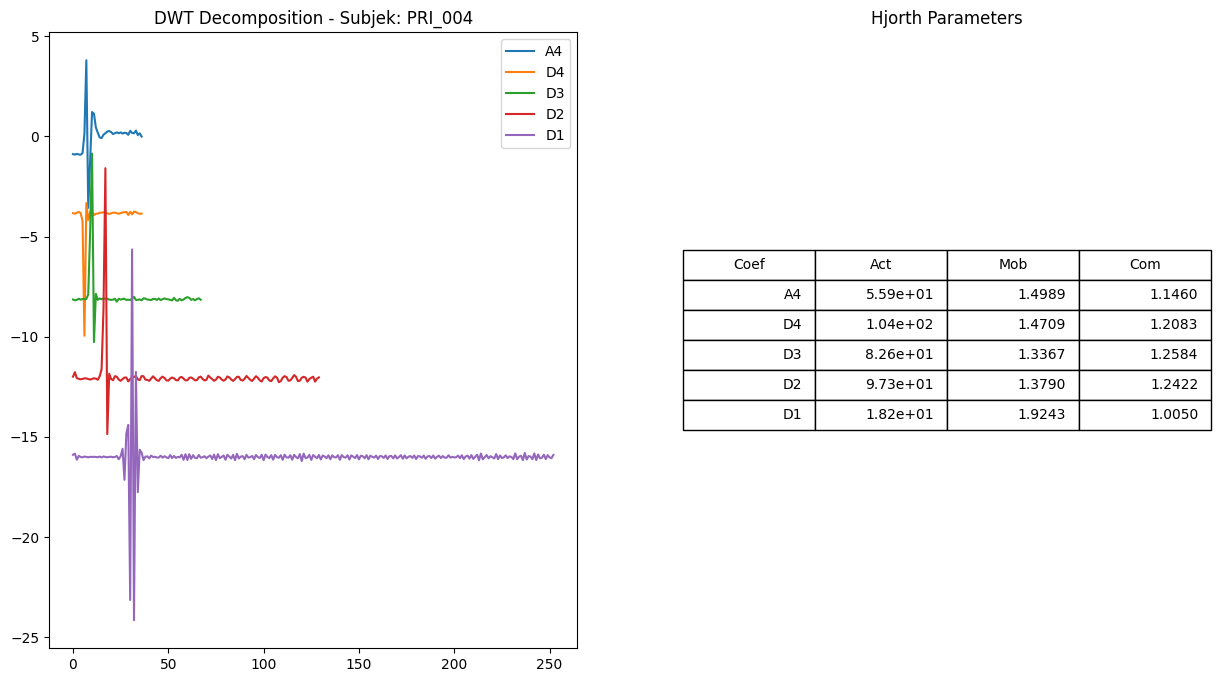

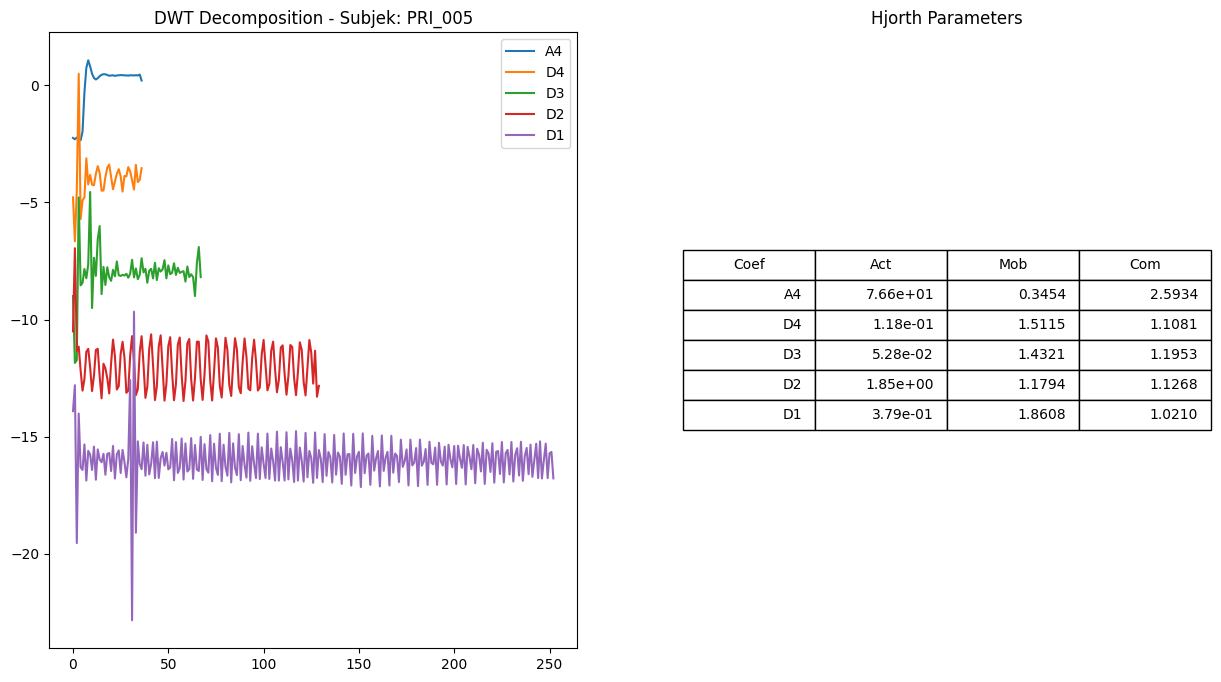

In [16]:
def visualisasi_fitur_dwt_hjorth(ref_idx=0):
    if 'refs' not in globals() or len(refs) == 0:
        return

    ref = refs[ref_idx]
    eeg, _ = preprocess_record(ref)
    epoch_size = int(4.0 * FS_TARGET)
    sig = eeg[0, :epoch_size]

    level = adaptive_dwt_level(epoch_size)
    coeffs = pywt.wavedec(sig, WAVELET, level=level)
    names = dwt_coefficient_names(level)

    fig = plt.figure(figsize=(15, 8))
    plt.subplot(1, 2, 1)
    for i, (c, name) in enumerate(zip(coeffs, names)):
        c_norm = (c - np.mean(c)) / (np.std(c) + 1e-12)
        plt.plot(c_norm - (i * 4), label=name)
    plt.title(f"DWT Decomposition - Subjek: {ref['subject_id']}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.axis('off')
    hjorth_data = [[name, f"{hjorth_parameters(c)[0]:.2e}", f"{hjorth_parameters(c)[1]:.4f}", f"{hjorth_parameters(c)[2]:.4f}"]
                   for c, name in zip(coeffs, names)]
    plt.table(cellText=hjorth_data, colLabels=['Coef', 'Act', 'Mob', 'Com'], loc='center').scale(1, 1.8)
    plt.title("Hjorth Parameters")
    plt.show()

# Menampilkan 5 Subjek Pertama
if 'refs' in globals() and len(refs) > 0:
    subject_list = []
    count = 0
    for i, r in enumerate(refs):
        if r['subject_id'] not in subject_list:
            visualisasi_fitur_dwt_hjorth(i)
            subject_list.append(r['subject_id'])
            count += 1
        if count >= 5: break